# **DATA PRE-PROCESSING**

In [2]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.tools import add_constant
from imblearn.over_sampling import SMOTE
import joblib

1. Load and read data

Dataset's descriptions:

Ten real-valued features are computed for each cell nucleus:

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry
	j) fractal dimension ("coastline approximation" - 1)


0 : malignant, 1 : benign
> There are only ten real-valued features; the other twenty are derived from these and are therefore highly correlated and considered redundant. Removing these twenty features is necessary, as they may cause multicollinearity.



In [3]:
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)

In [4]:
df.shape

(569, 30)

In [5]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
redundantCols = [col for col in df.columns if "worst" in col or "error" in col] # Get cols contain "worst" or "error"
df = df.drop(labels=redundantCols, axis=1) # Removing redundant information

In [7]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883
...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016


2. Sanity check of data

In [8]:
df.info() # Check info, Note: if a column's Dtype is object then it is considered garbage value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   mean radius             569 non-null    float64
 1   mean texture            569 non-null    float64
 2   mean perimeter          569 non-null    float64
 3   mean area               569 non-null    float64
 4   mean smoothness         569 non-null    float64
 5   mean compactness        569 non-null    float64
 6   mean concavity          569 non-null    float64
 7   mean concave points     569 non-null    float64
 8   mean symmetry           569 non-null    float64
 9   mean fractal dimension  569 non-null    float64
dtypes: float64(10)
memory usage: 44.6 KB


In [9]:
df.isna().sum() # Check for missing values

mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

In [10]:
df.duplicated().sum() # Check for duplicates

0

Note: if the dataset has missing values, duplicates or garbage values, they needs to be properly addessed -- such as filling, dropping, or cleaning them.

3. Exploratory Data Analysis (EDA)

In [11]:
df.describe().T # descriptive statistics

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


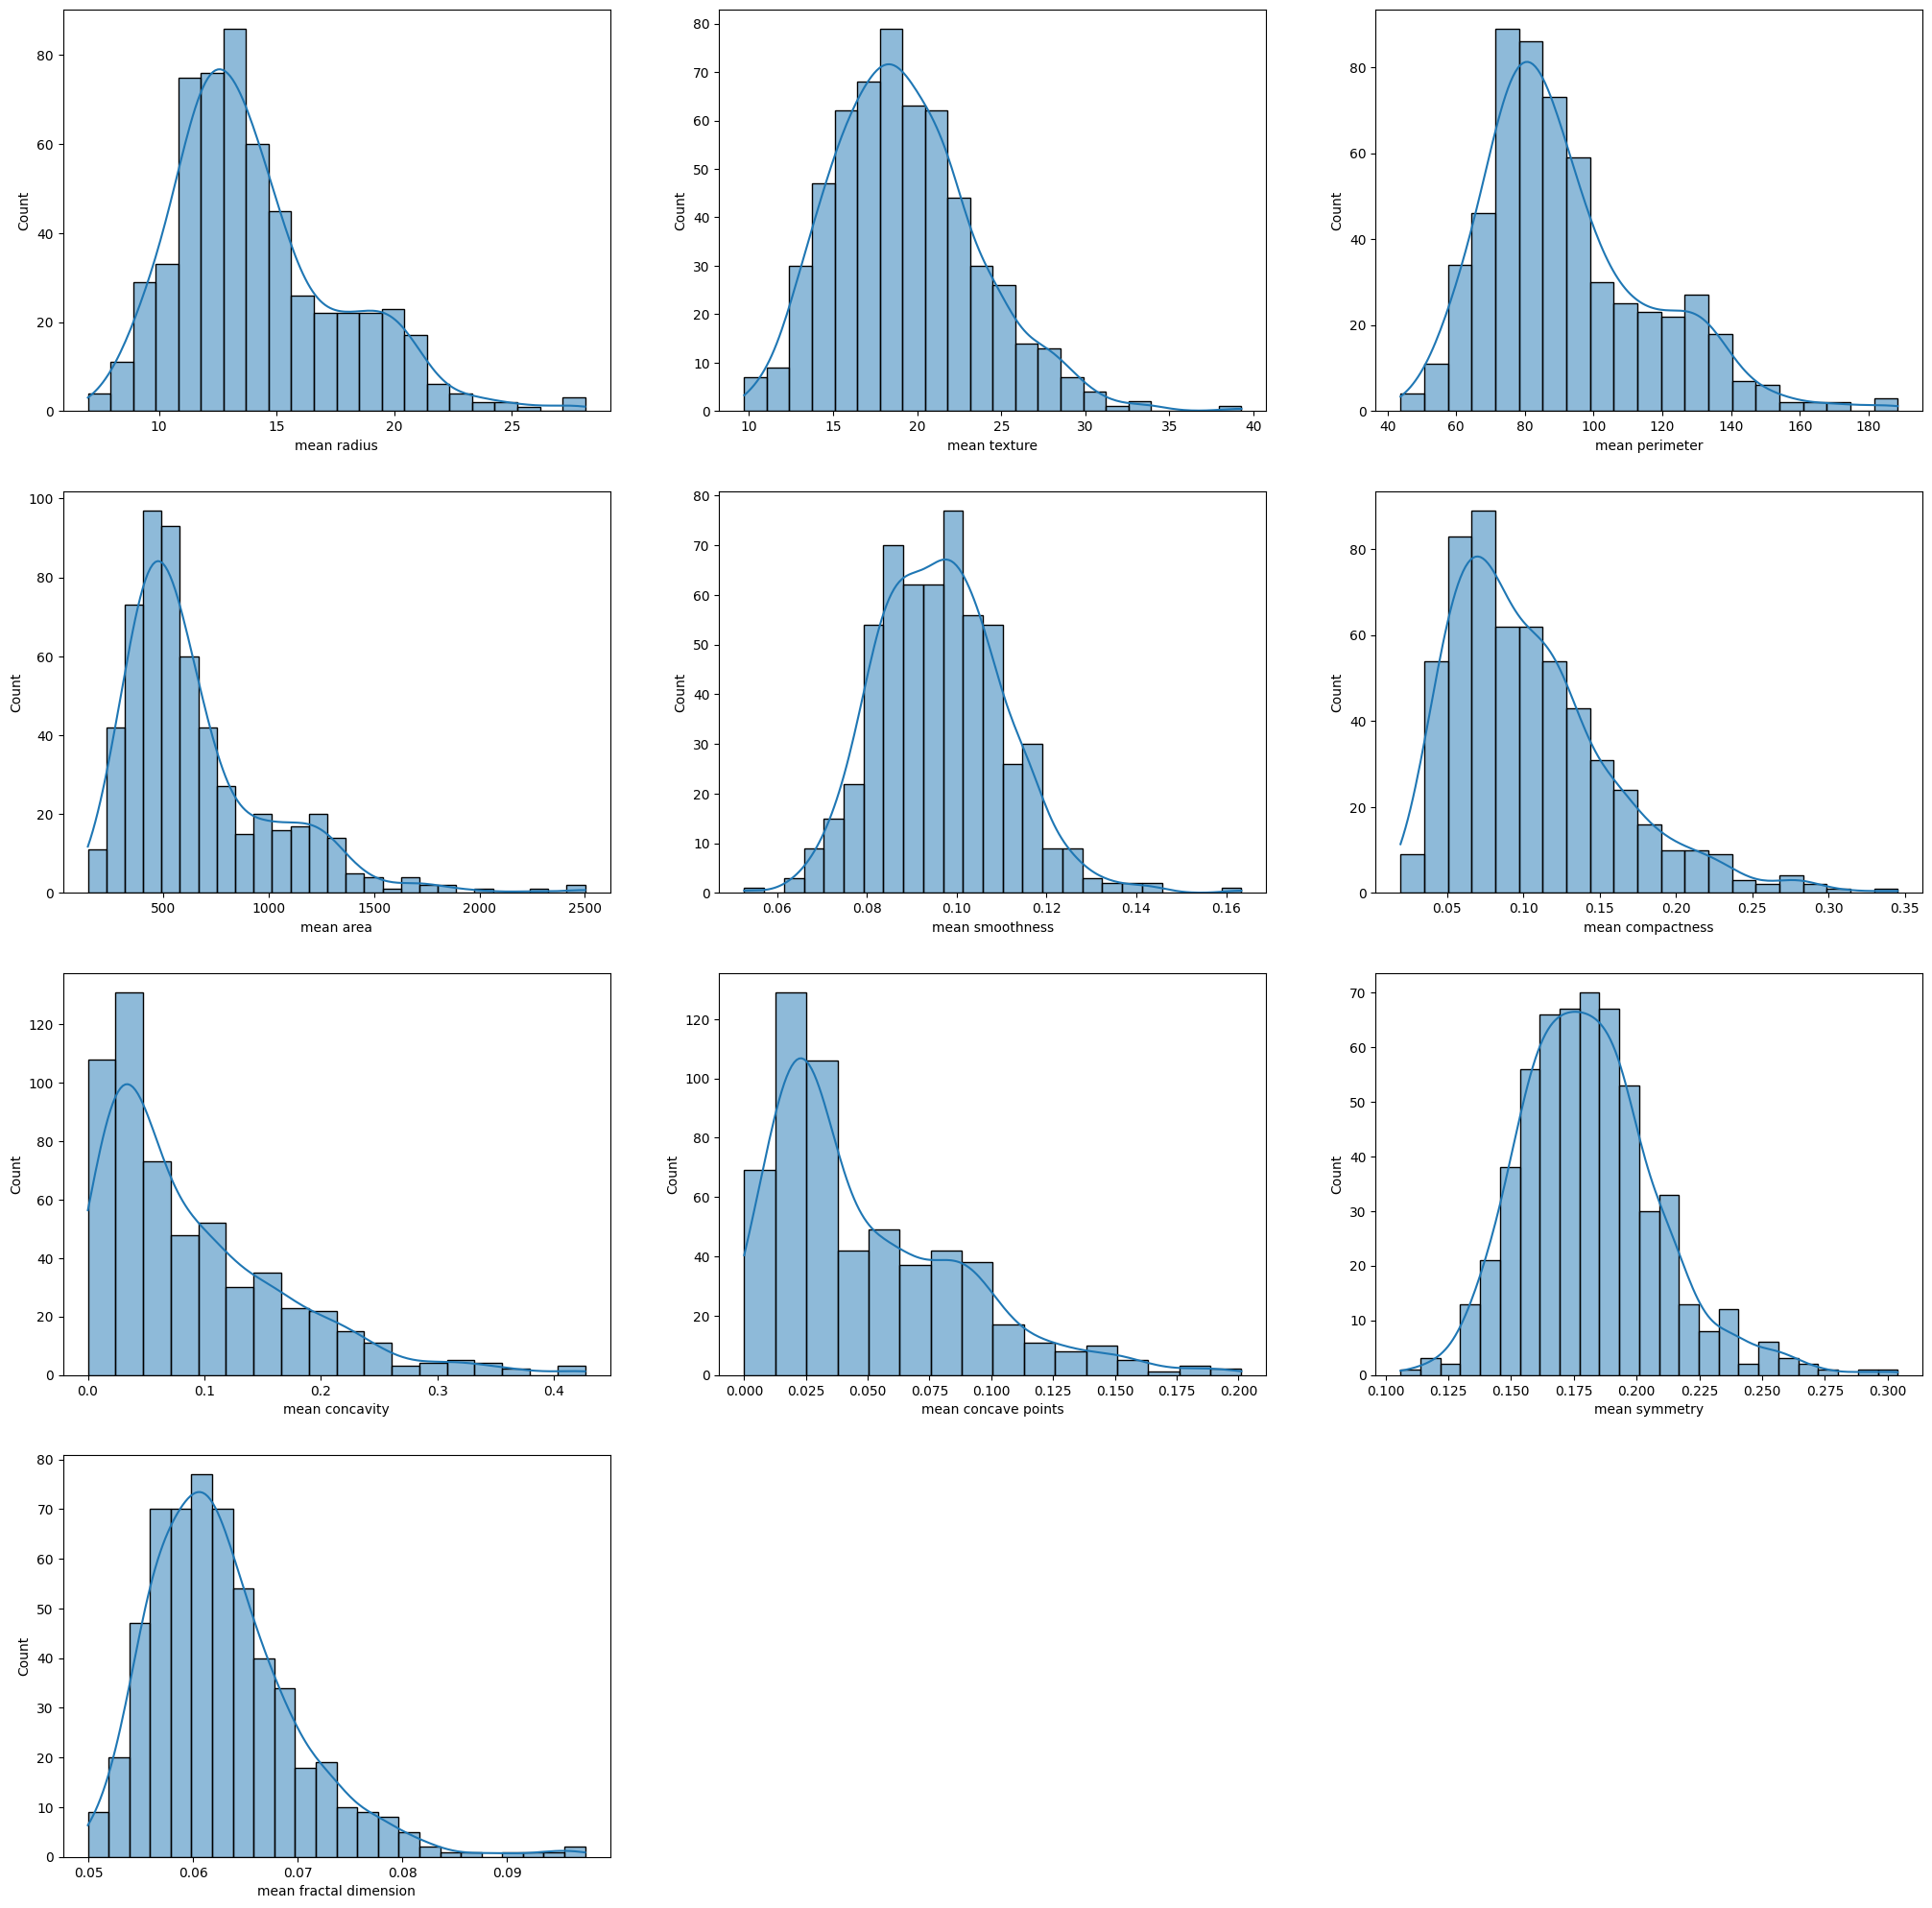

In [12]:
# histogram plot to understand the distribution
plt.figure(figsize=(25, 25))
for i in range(len(df.columns)):
  plt.subplot(4, 3, i + 1)
  sns.histplot(data=df, x=df.columns[i], kde=True)
plt.show()

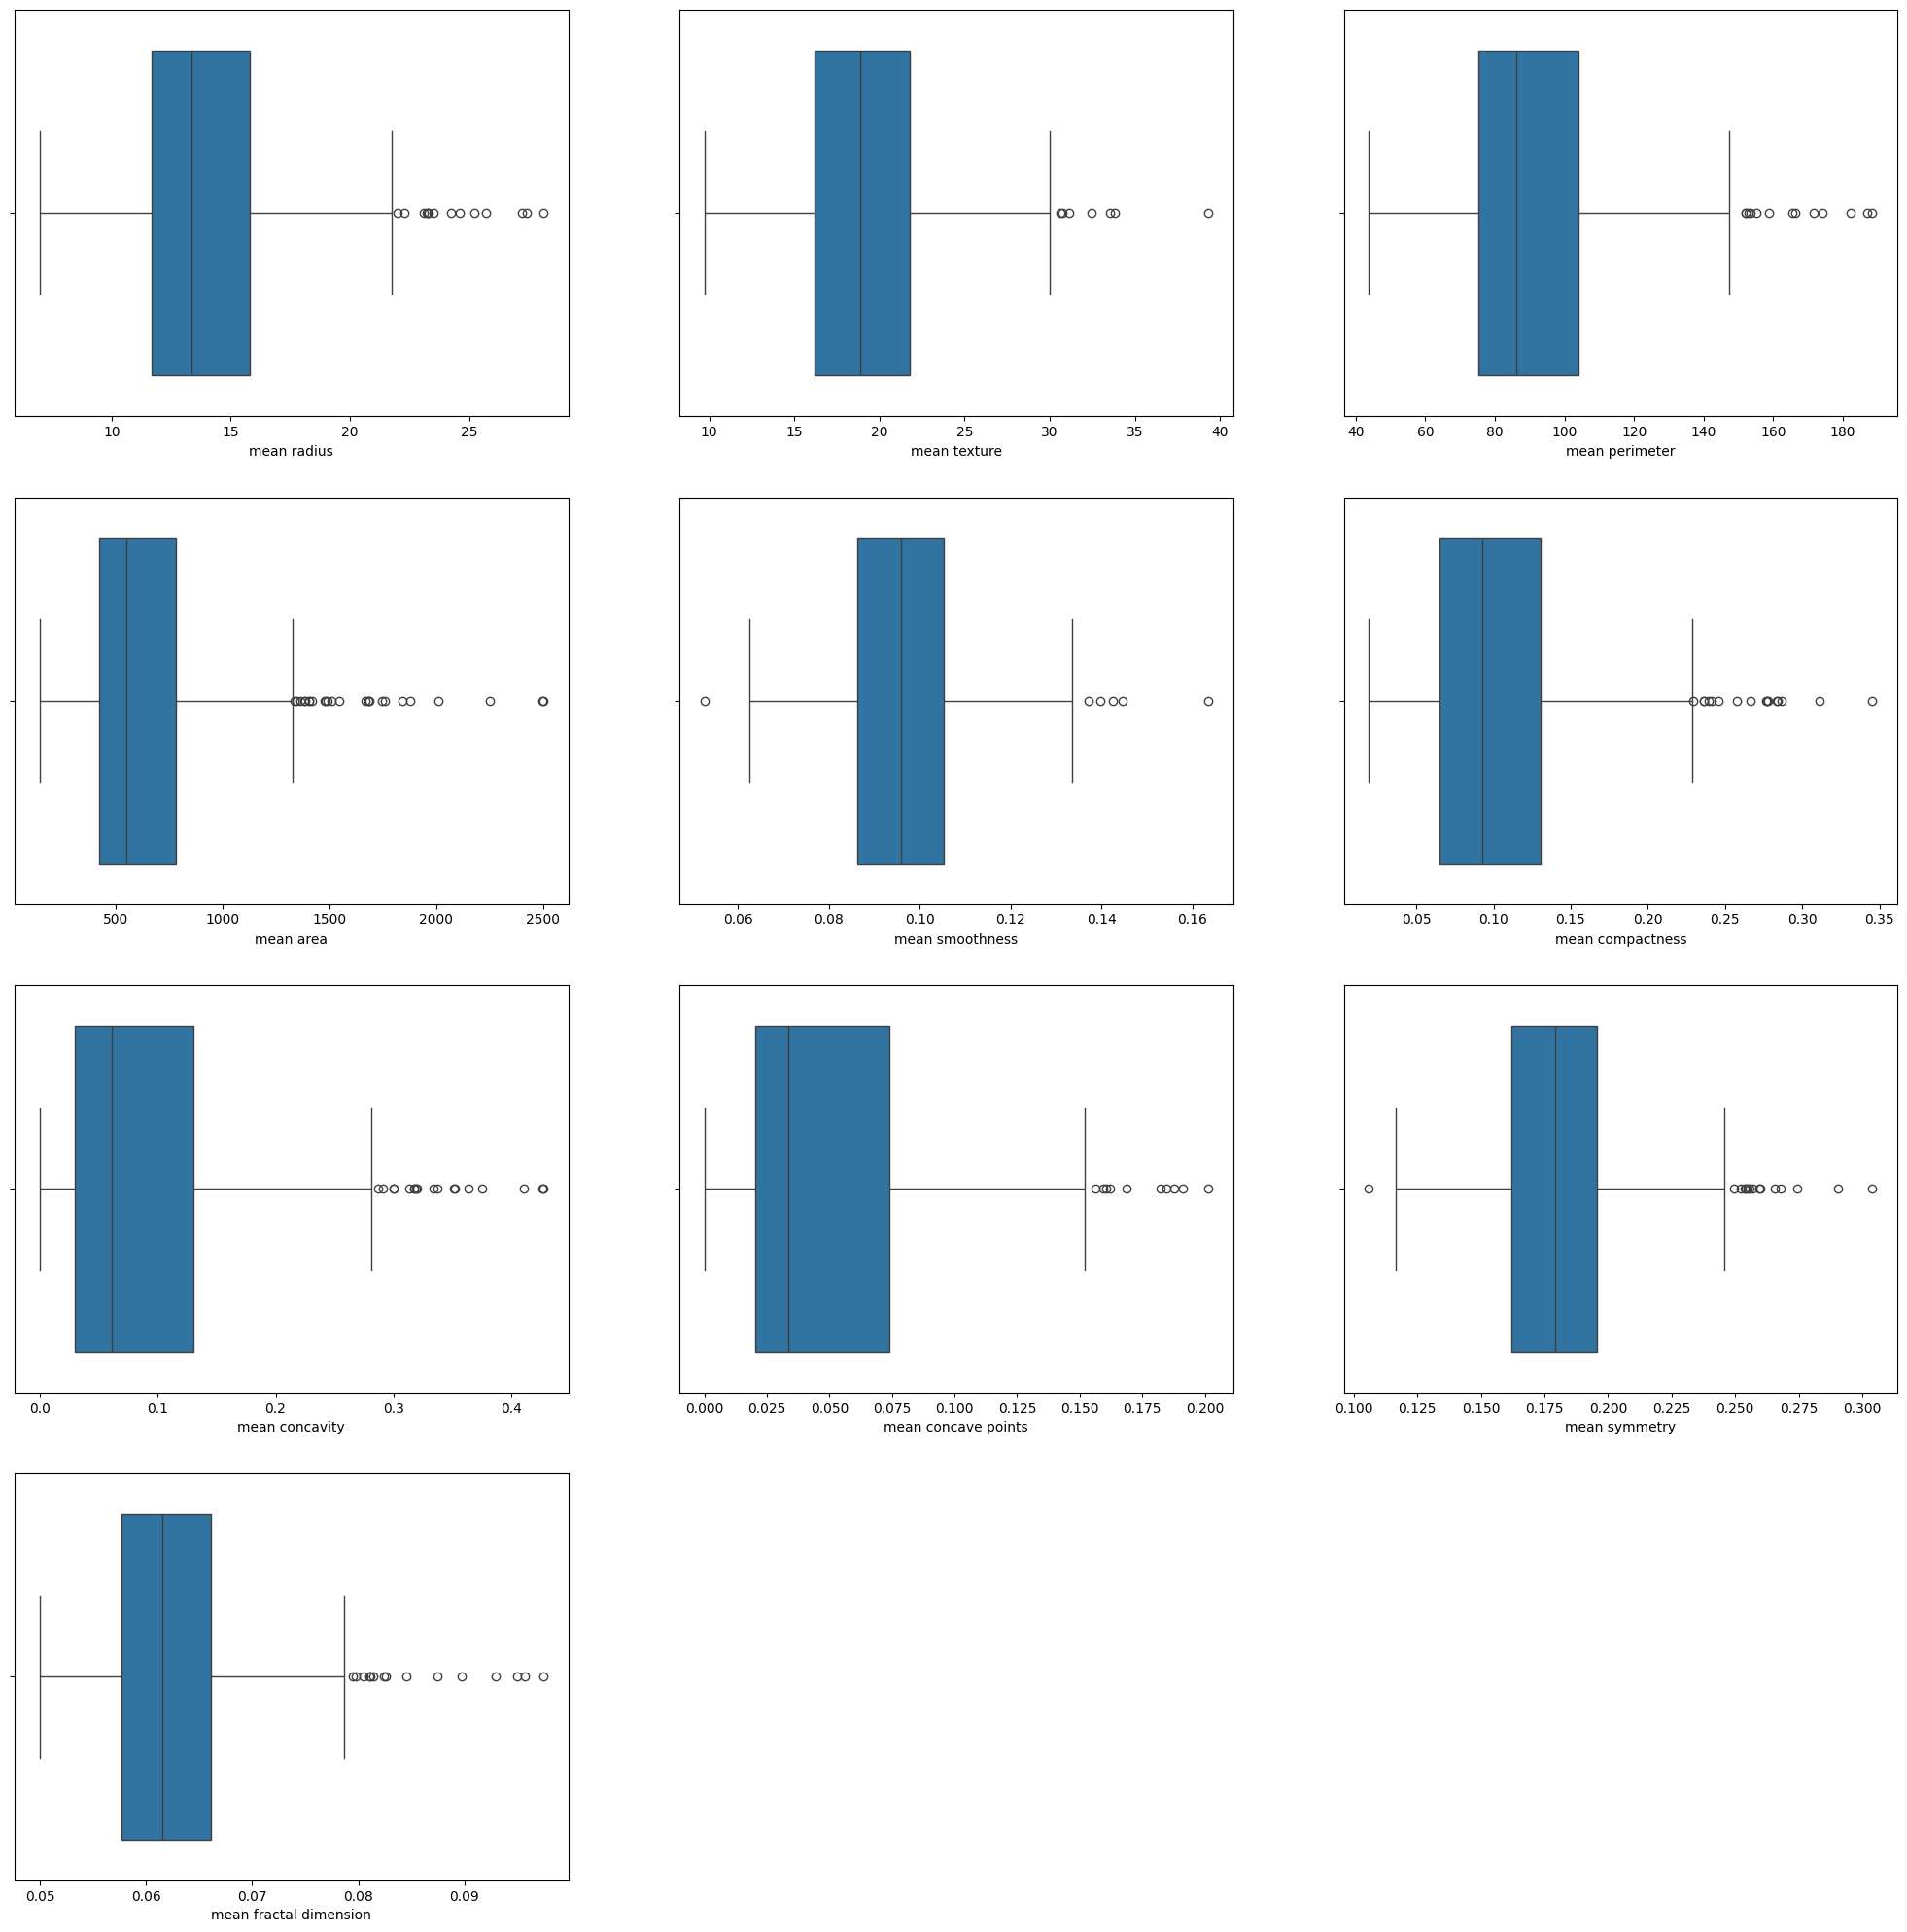

In [13]:
# boxplot to indentify outliers
plt.figure(figsize=(25, 25))
for i in range(len(df.columns)):
  plt.subplot(4, 3, i + 1)
  sns.boxplot(data=df, x=df.columns[i])
plt.show()

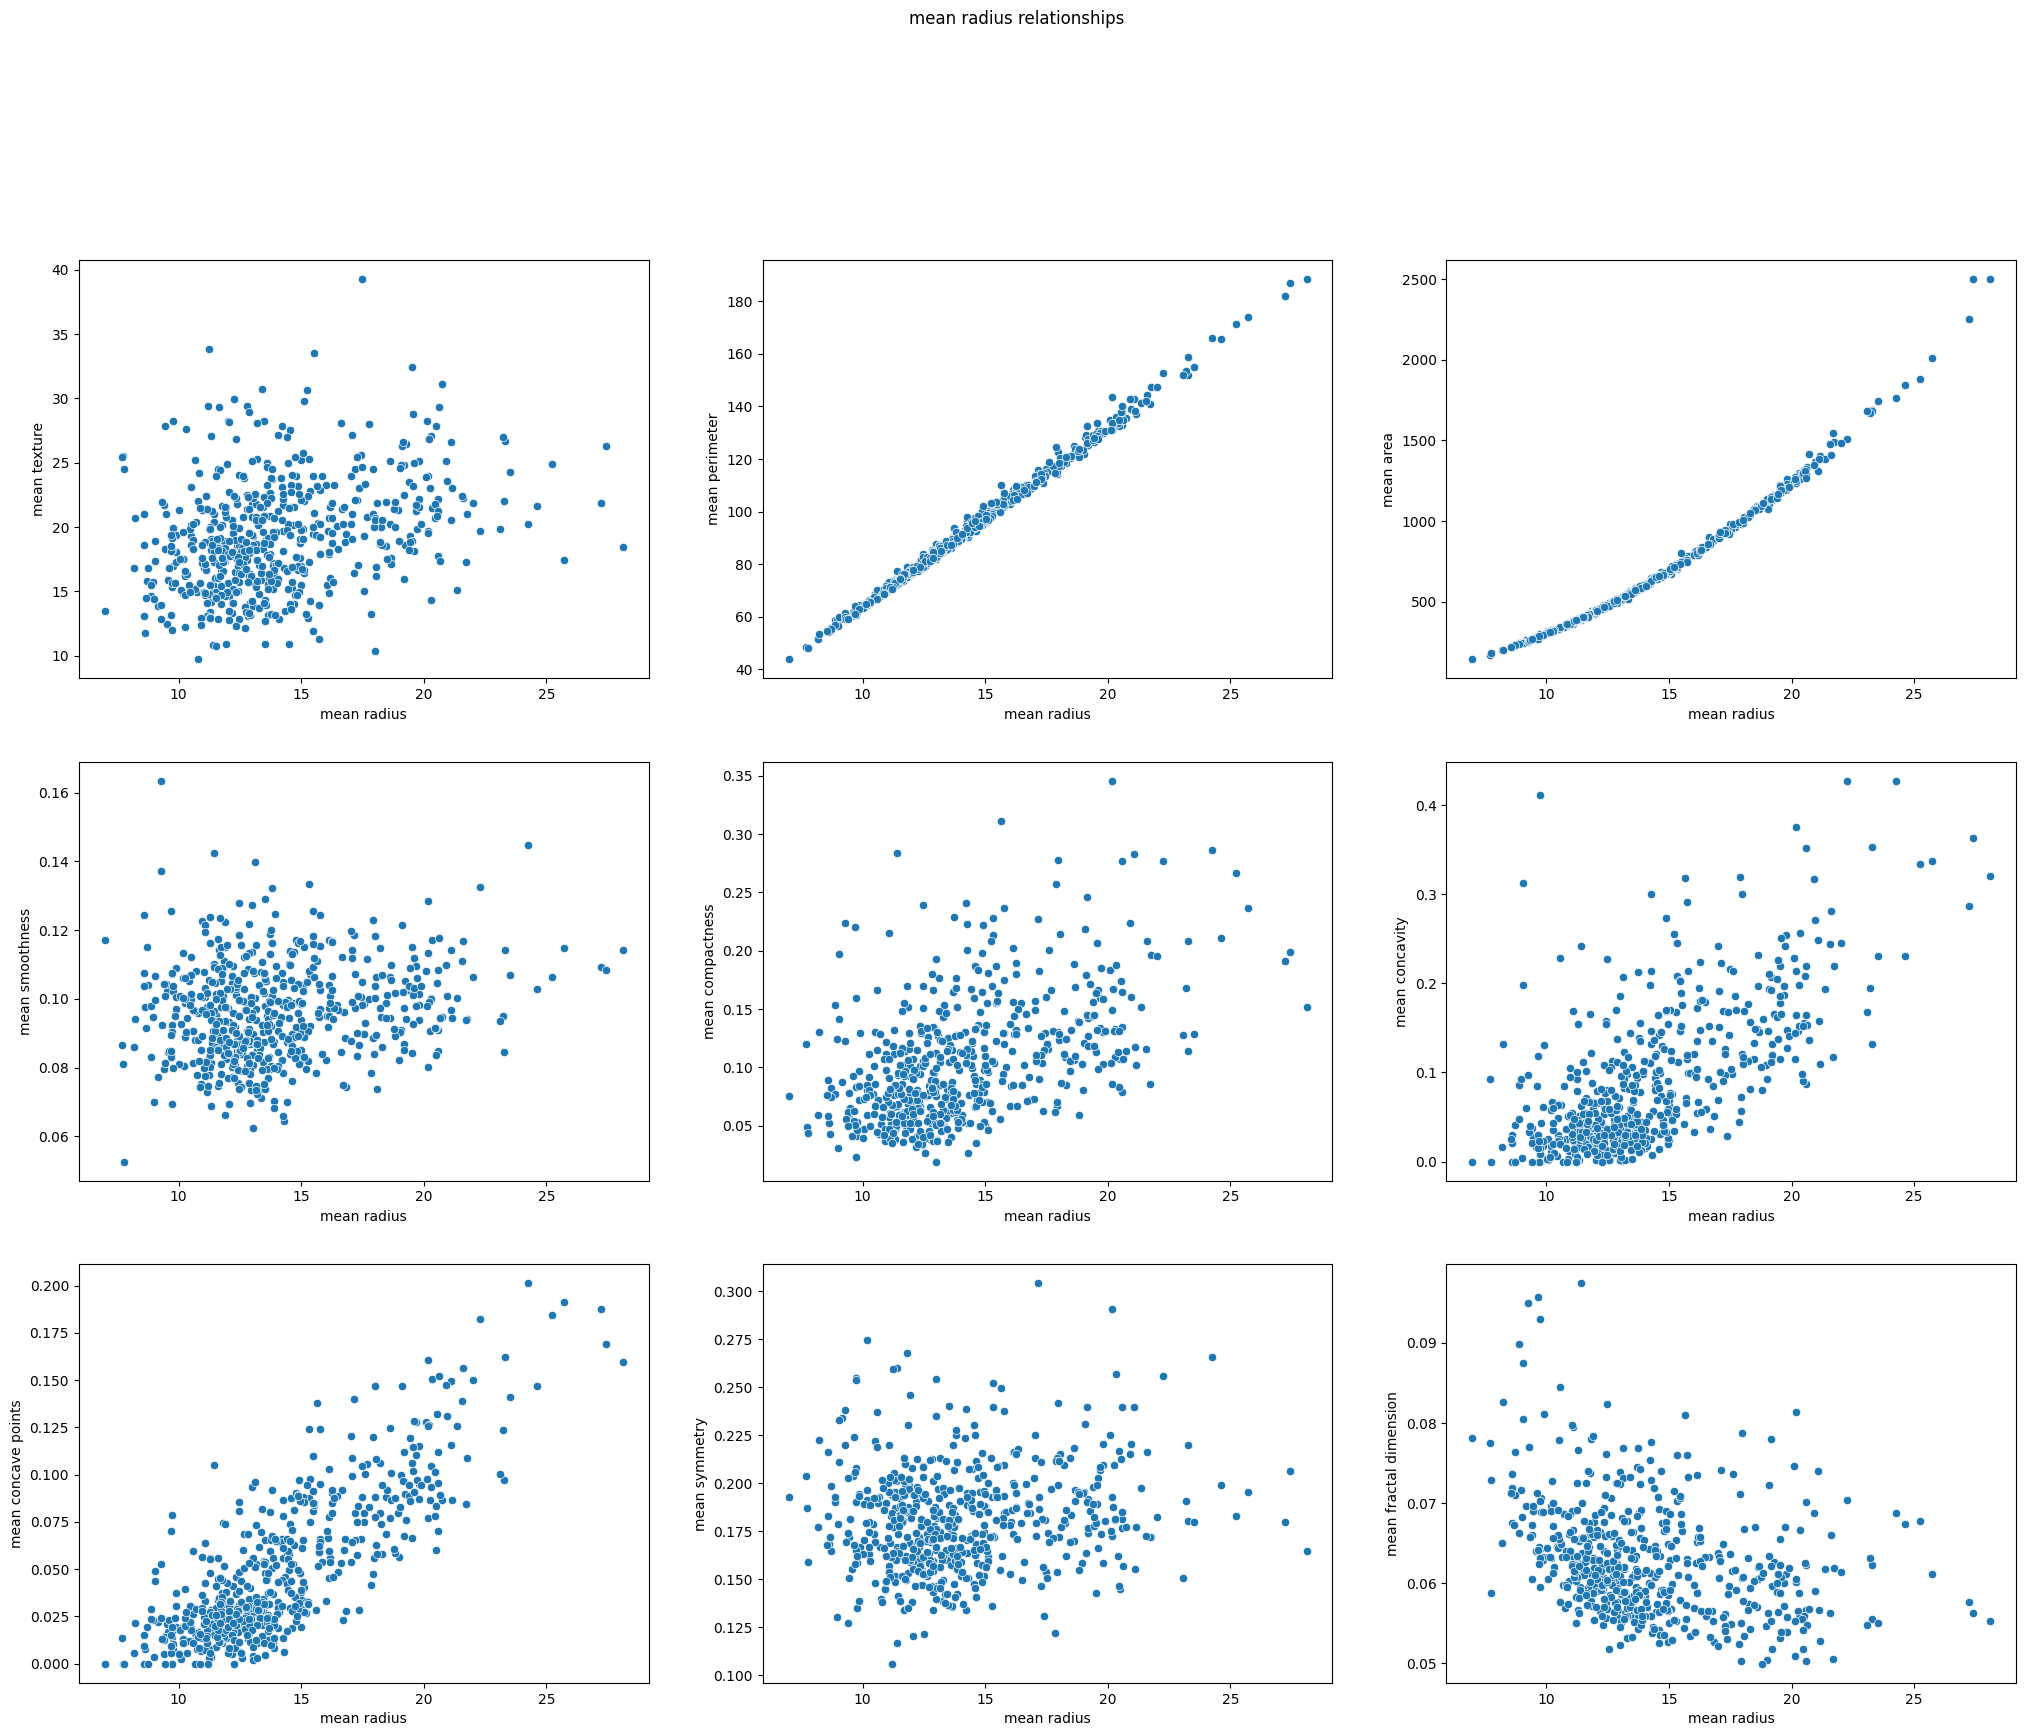

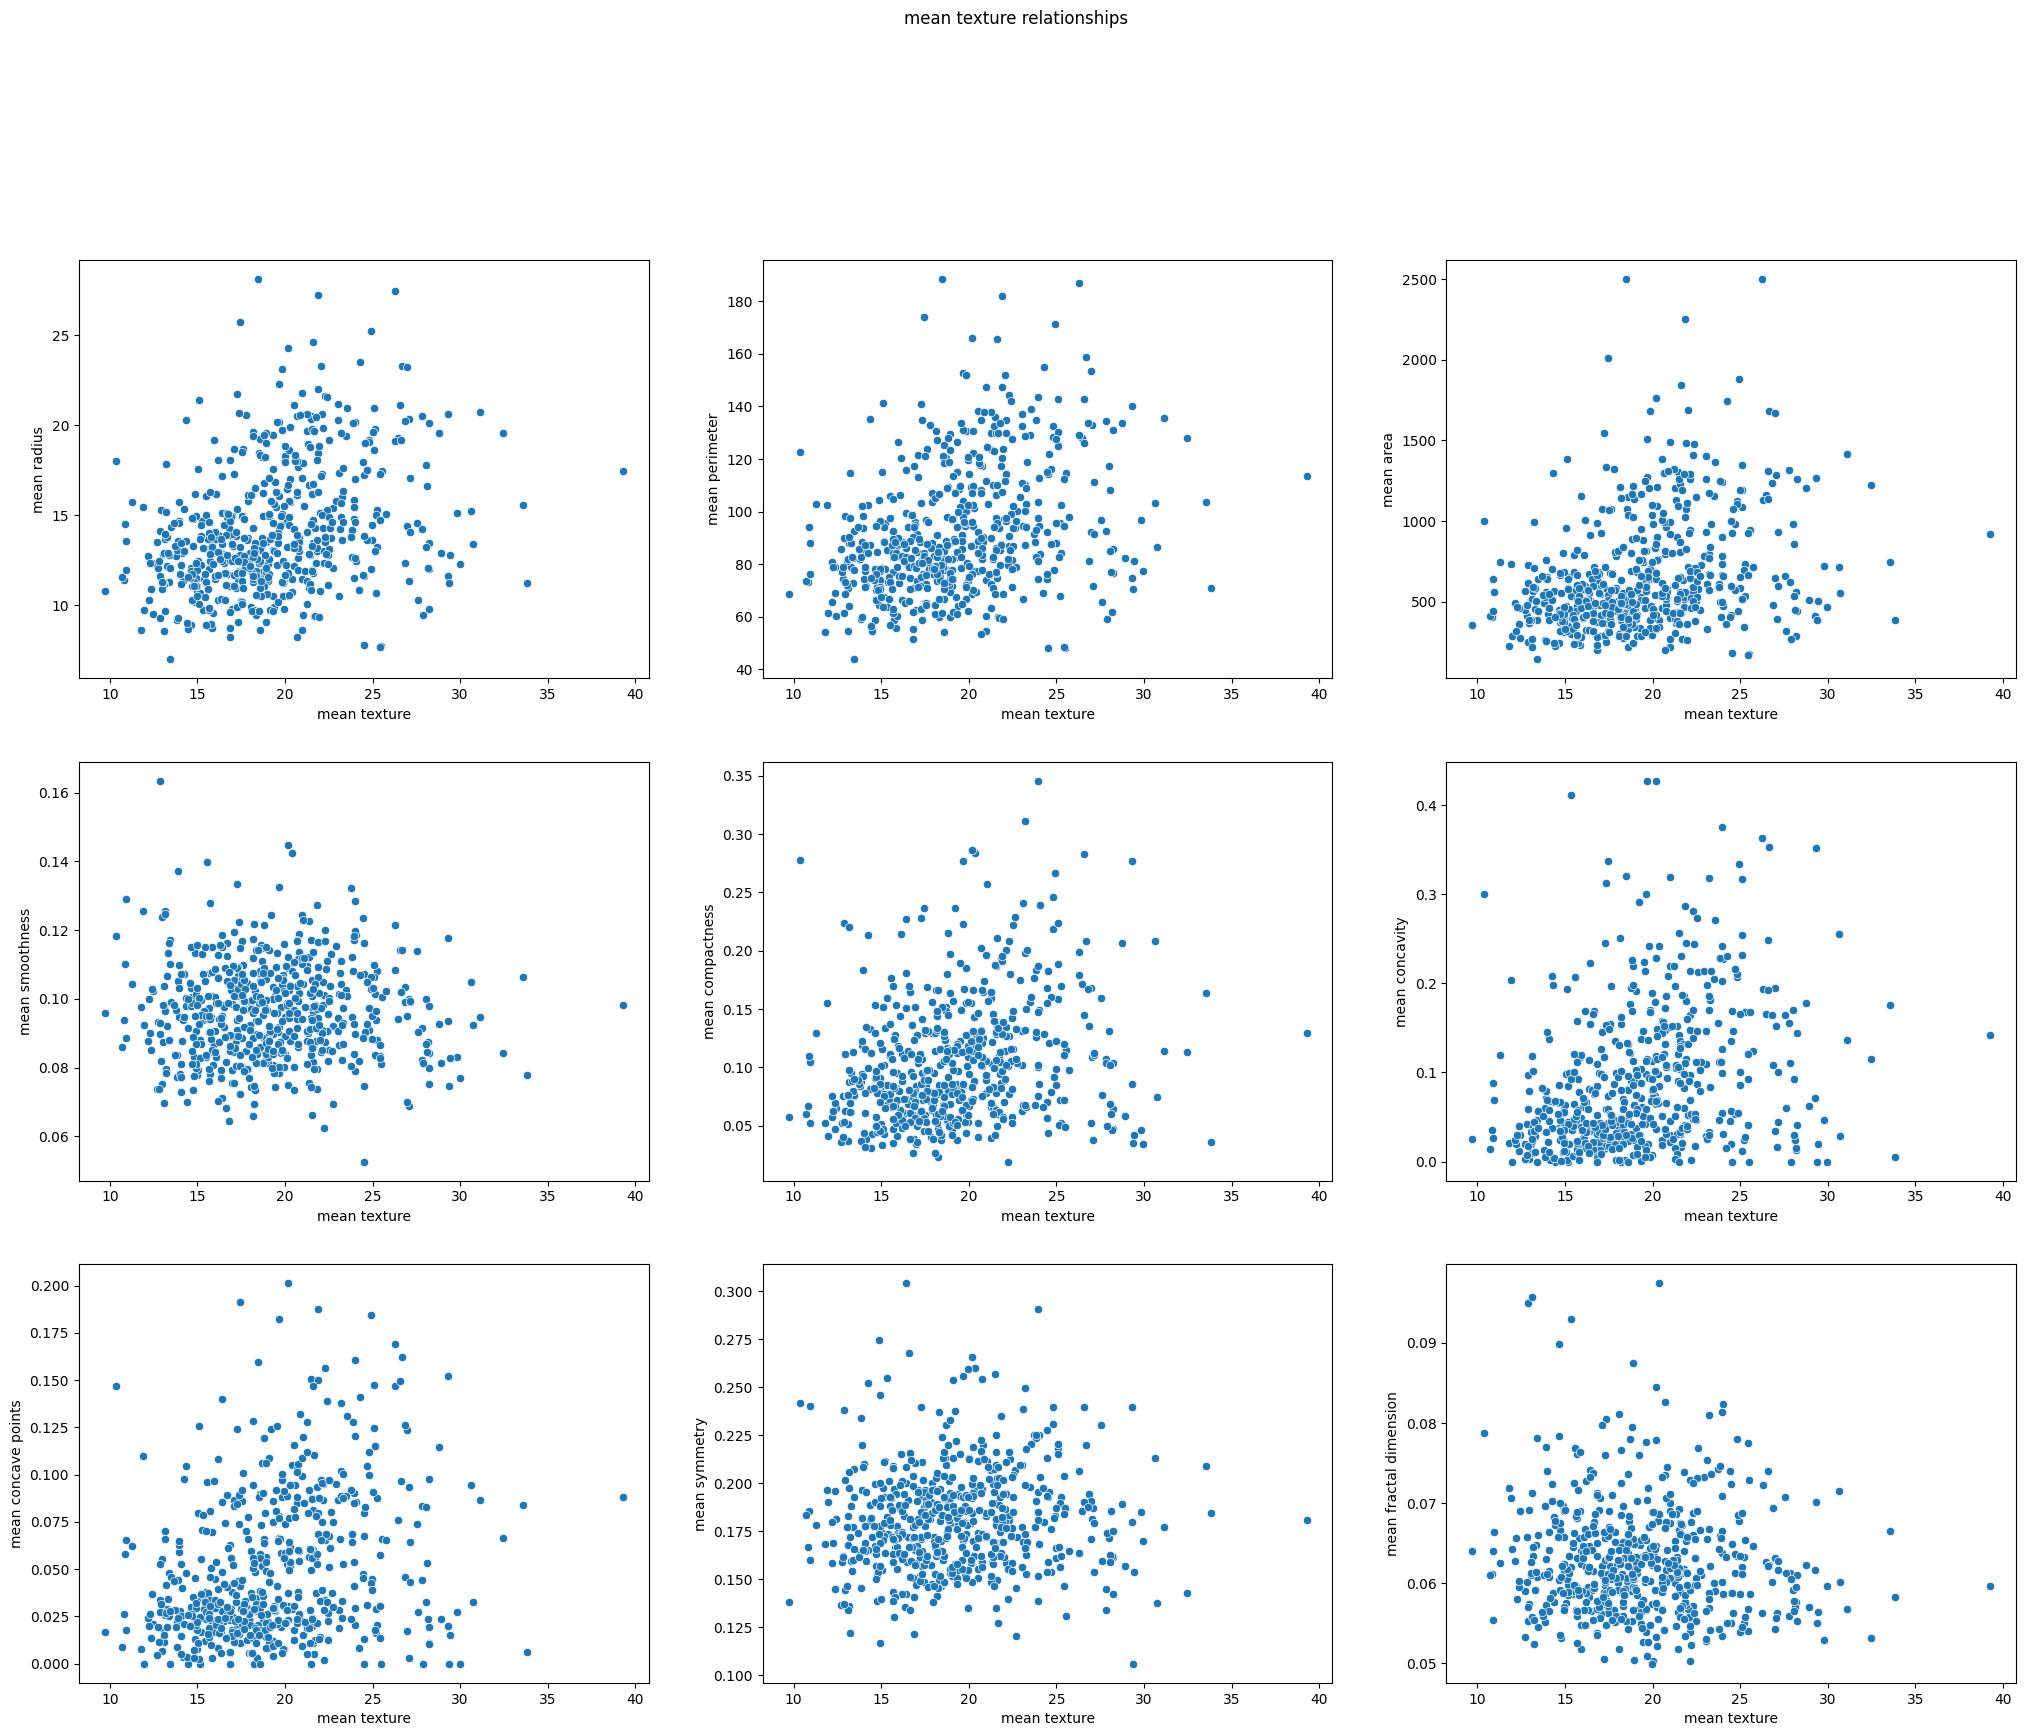

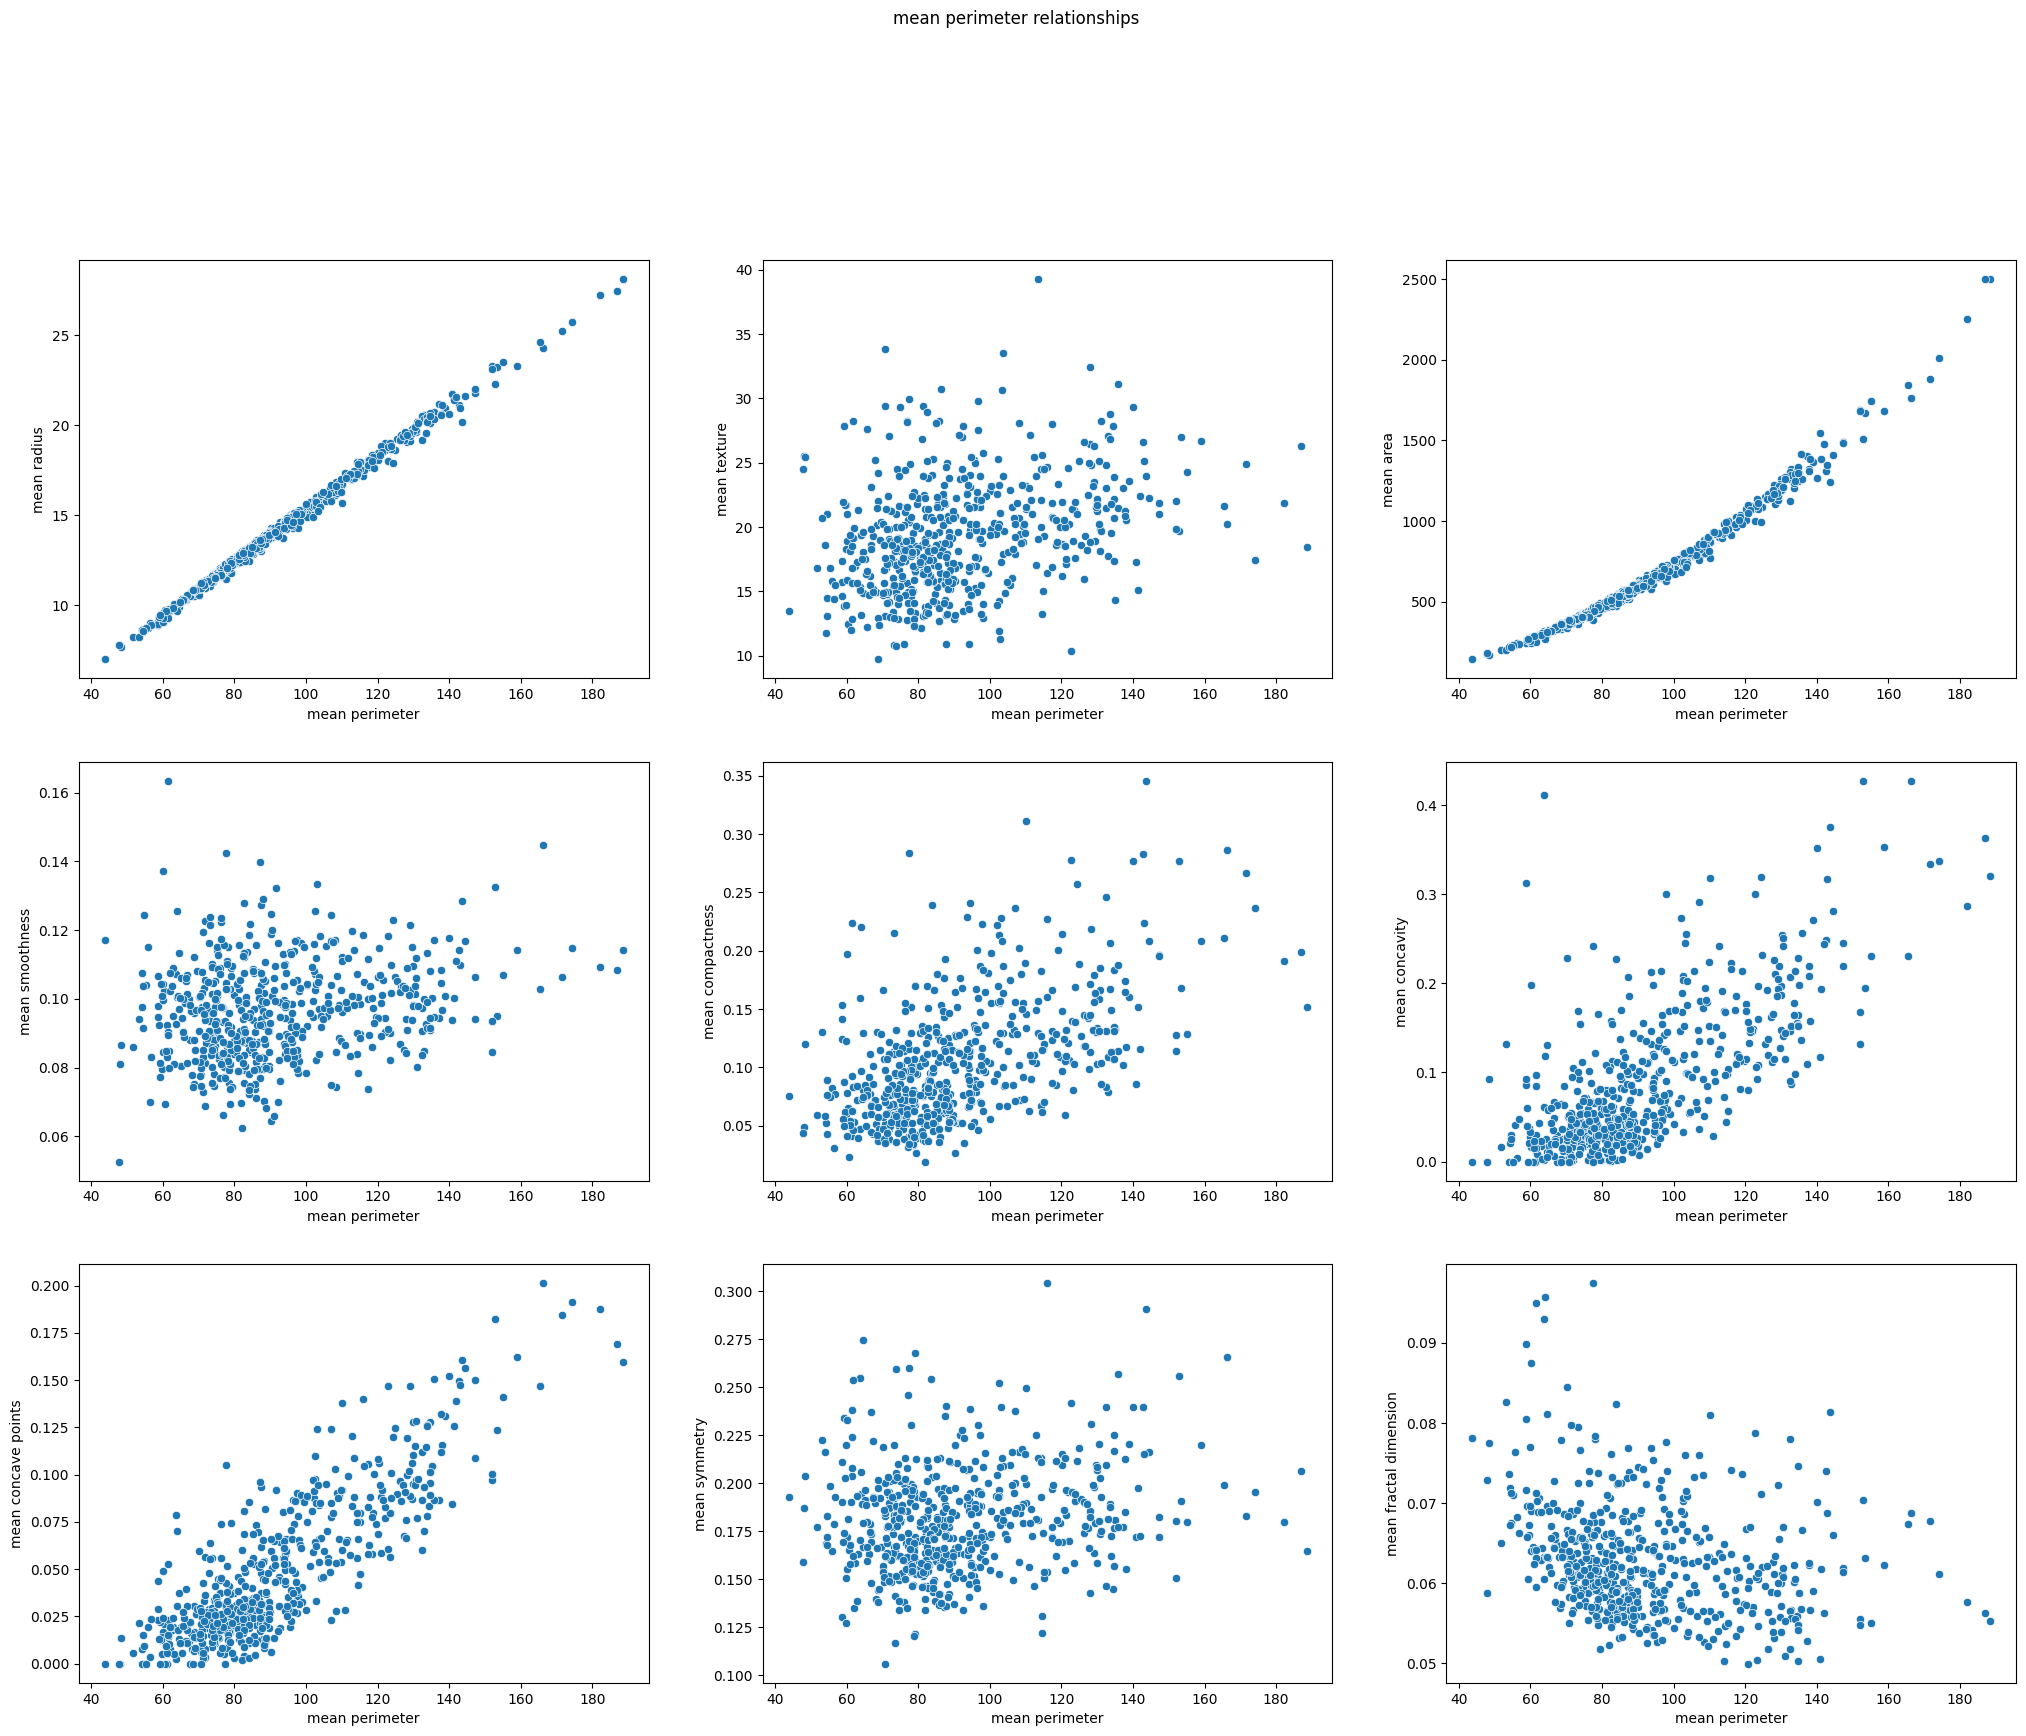

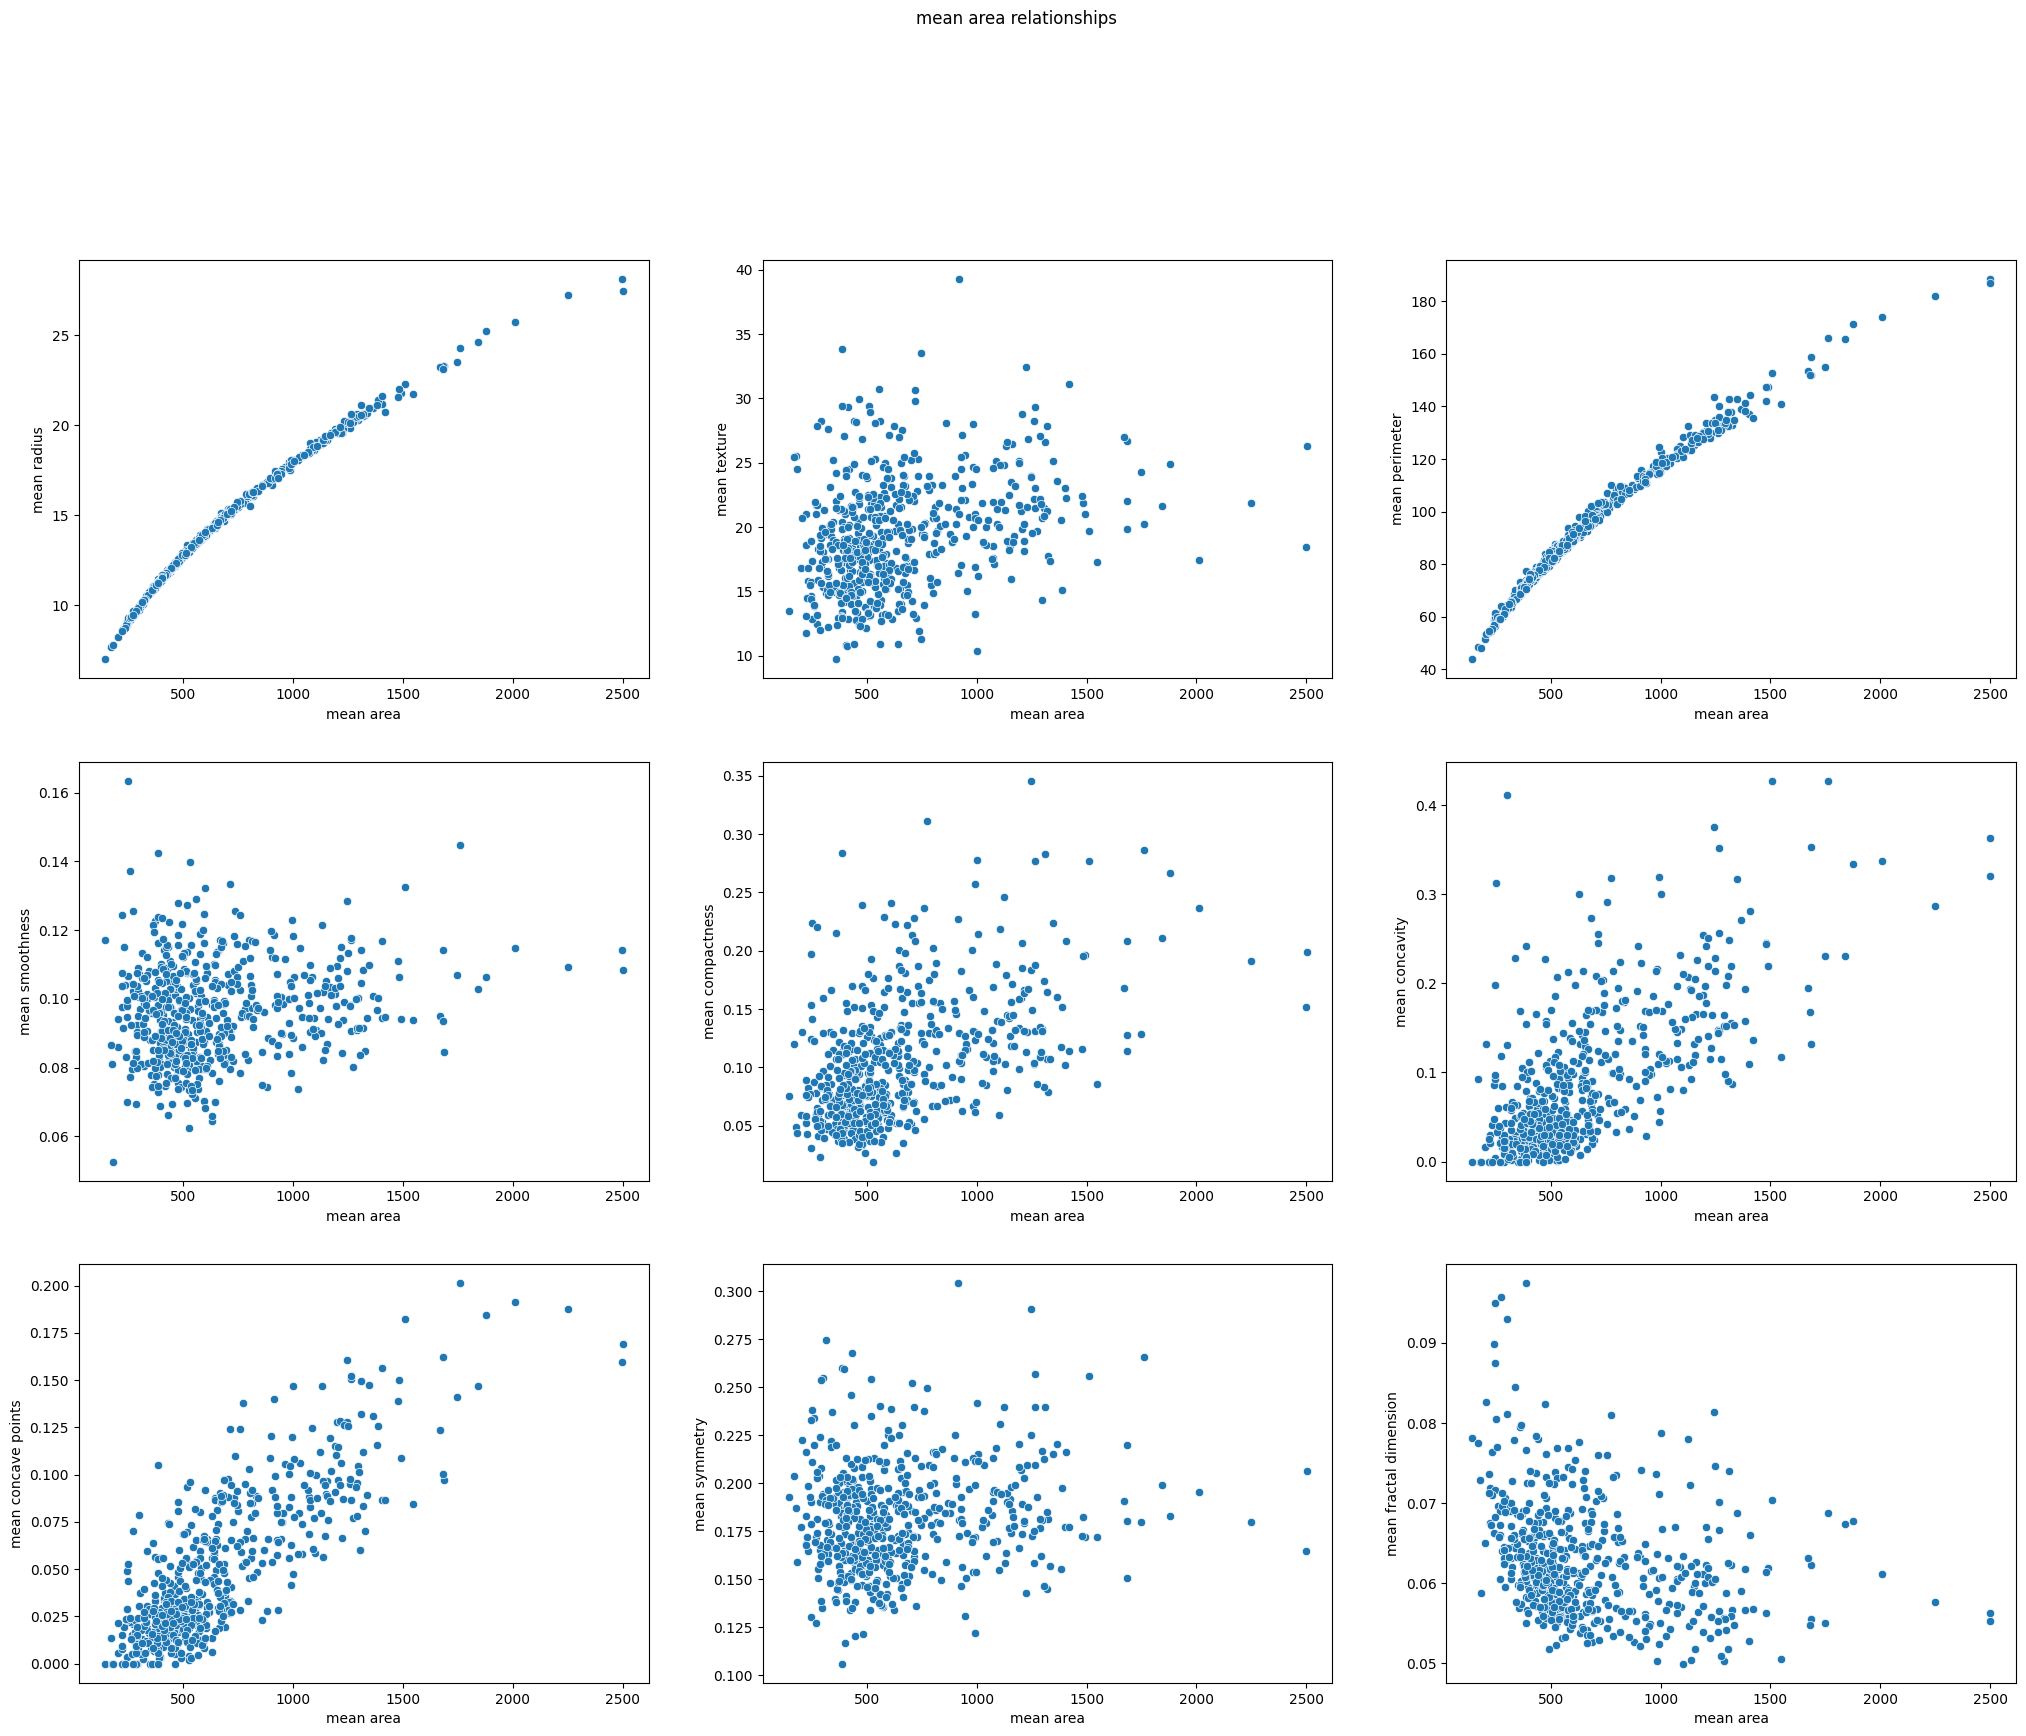

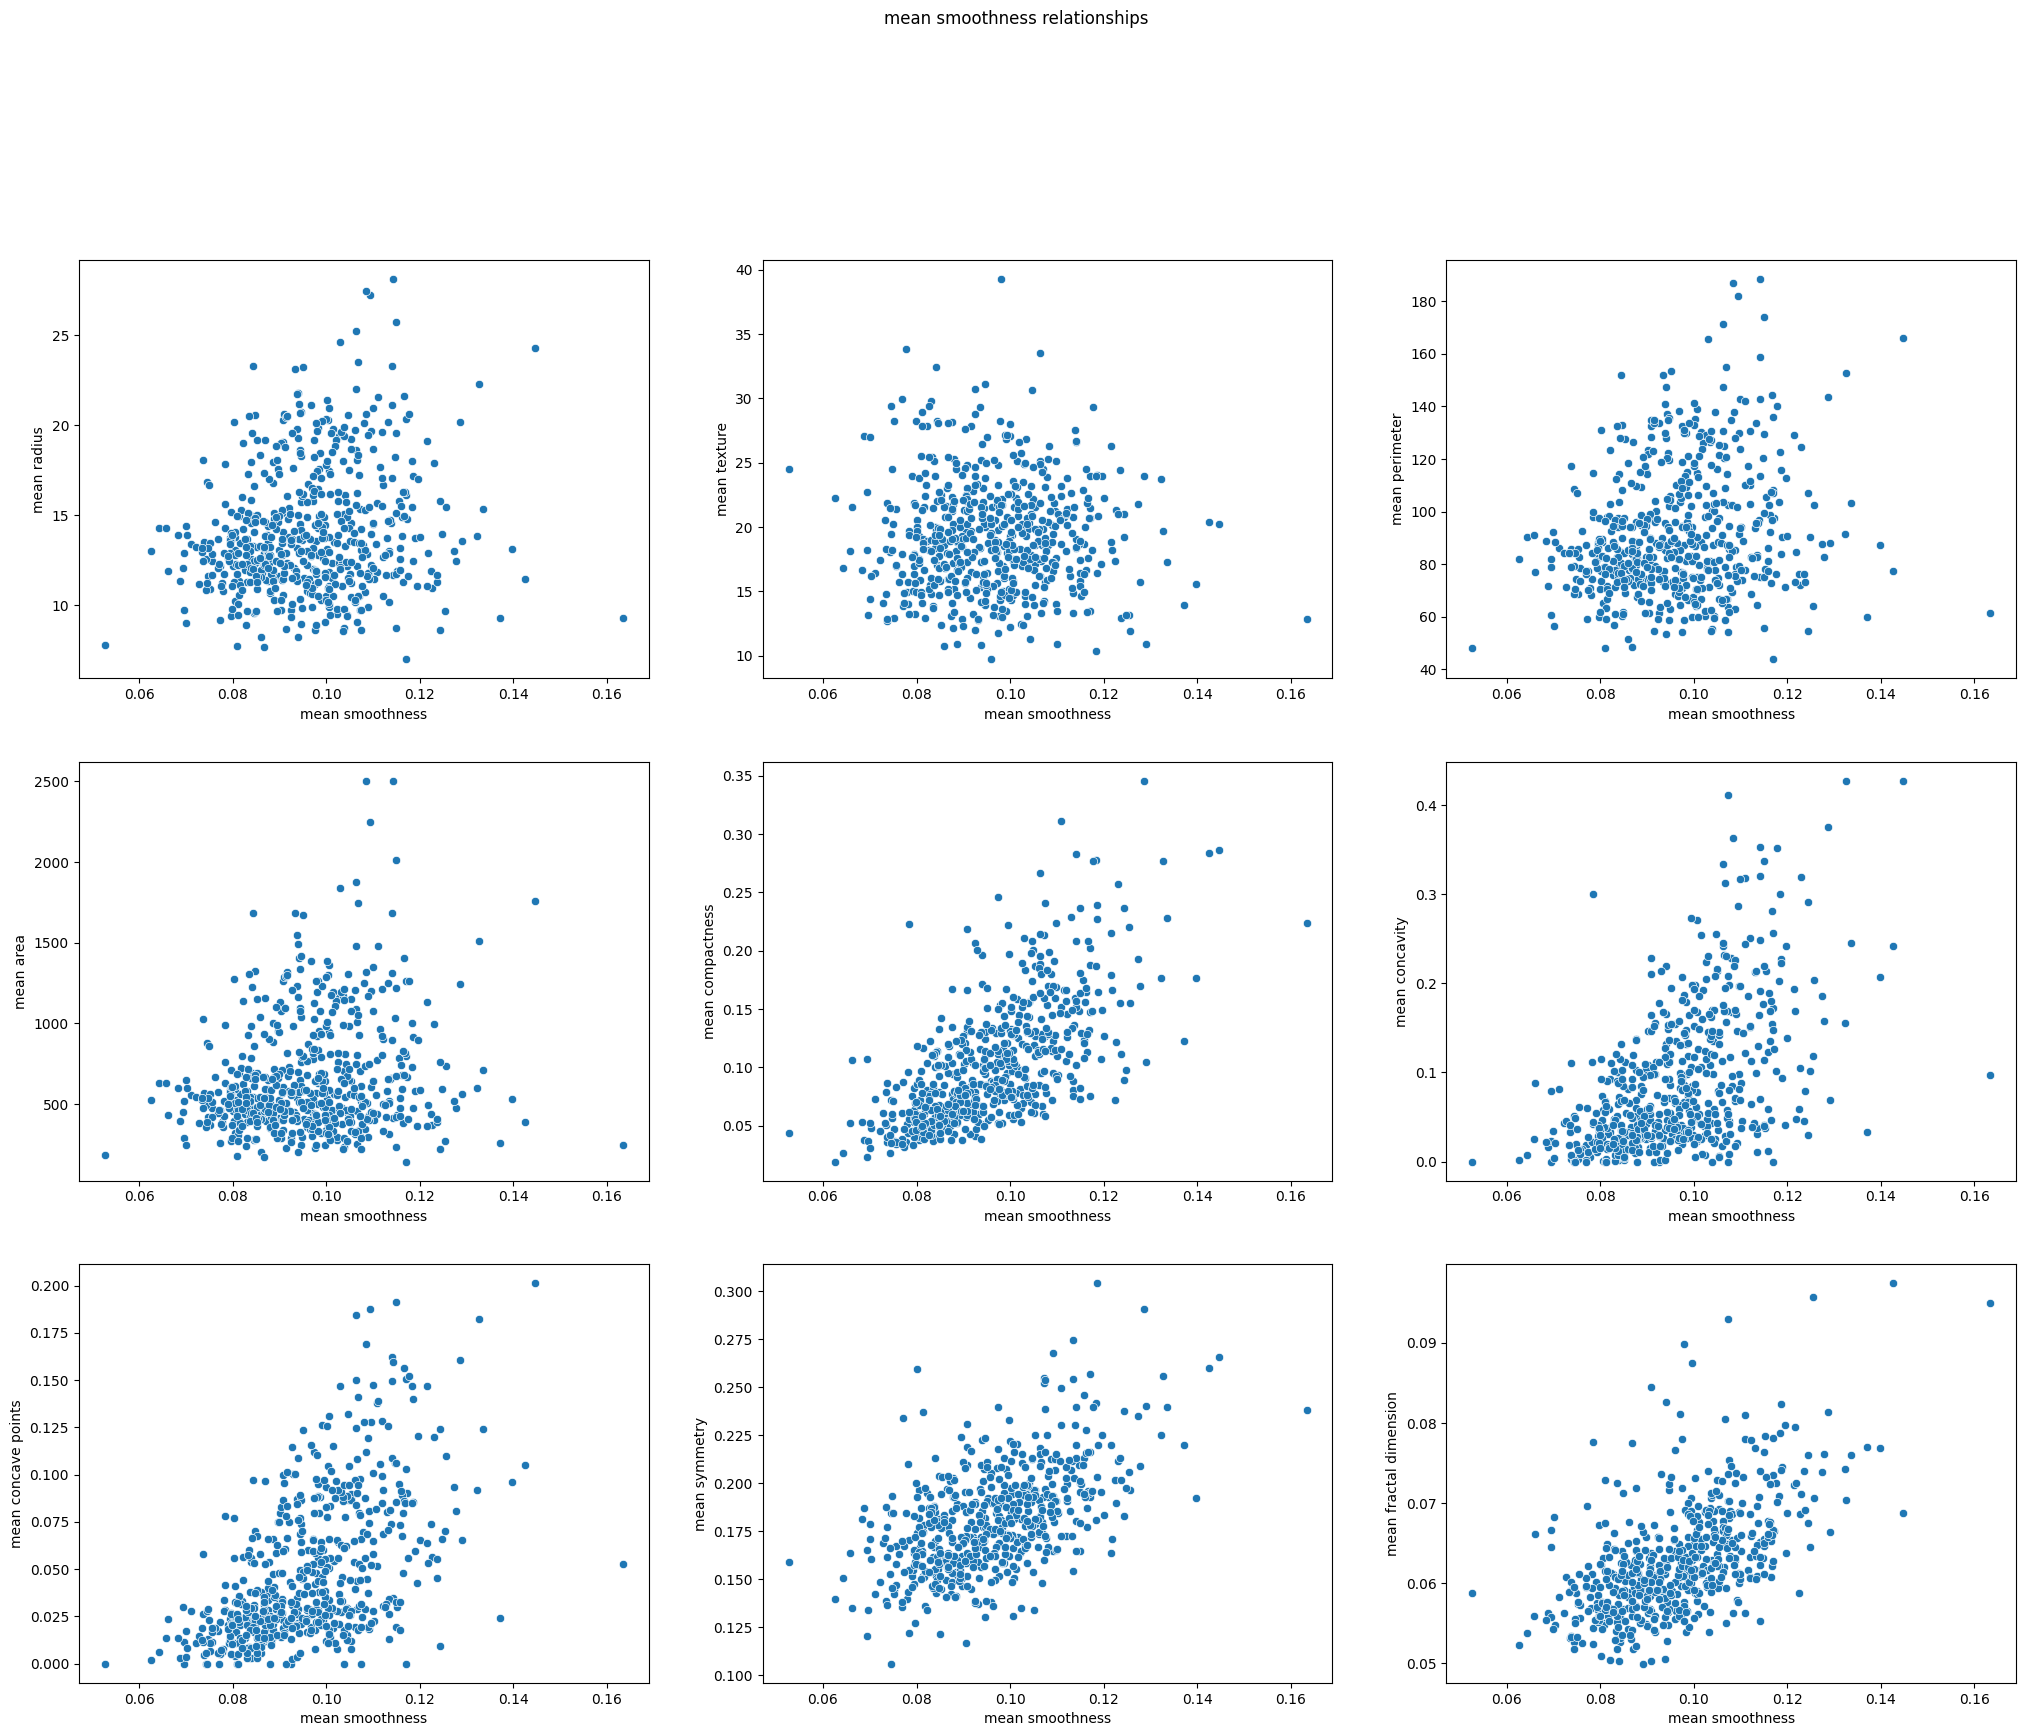

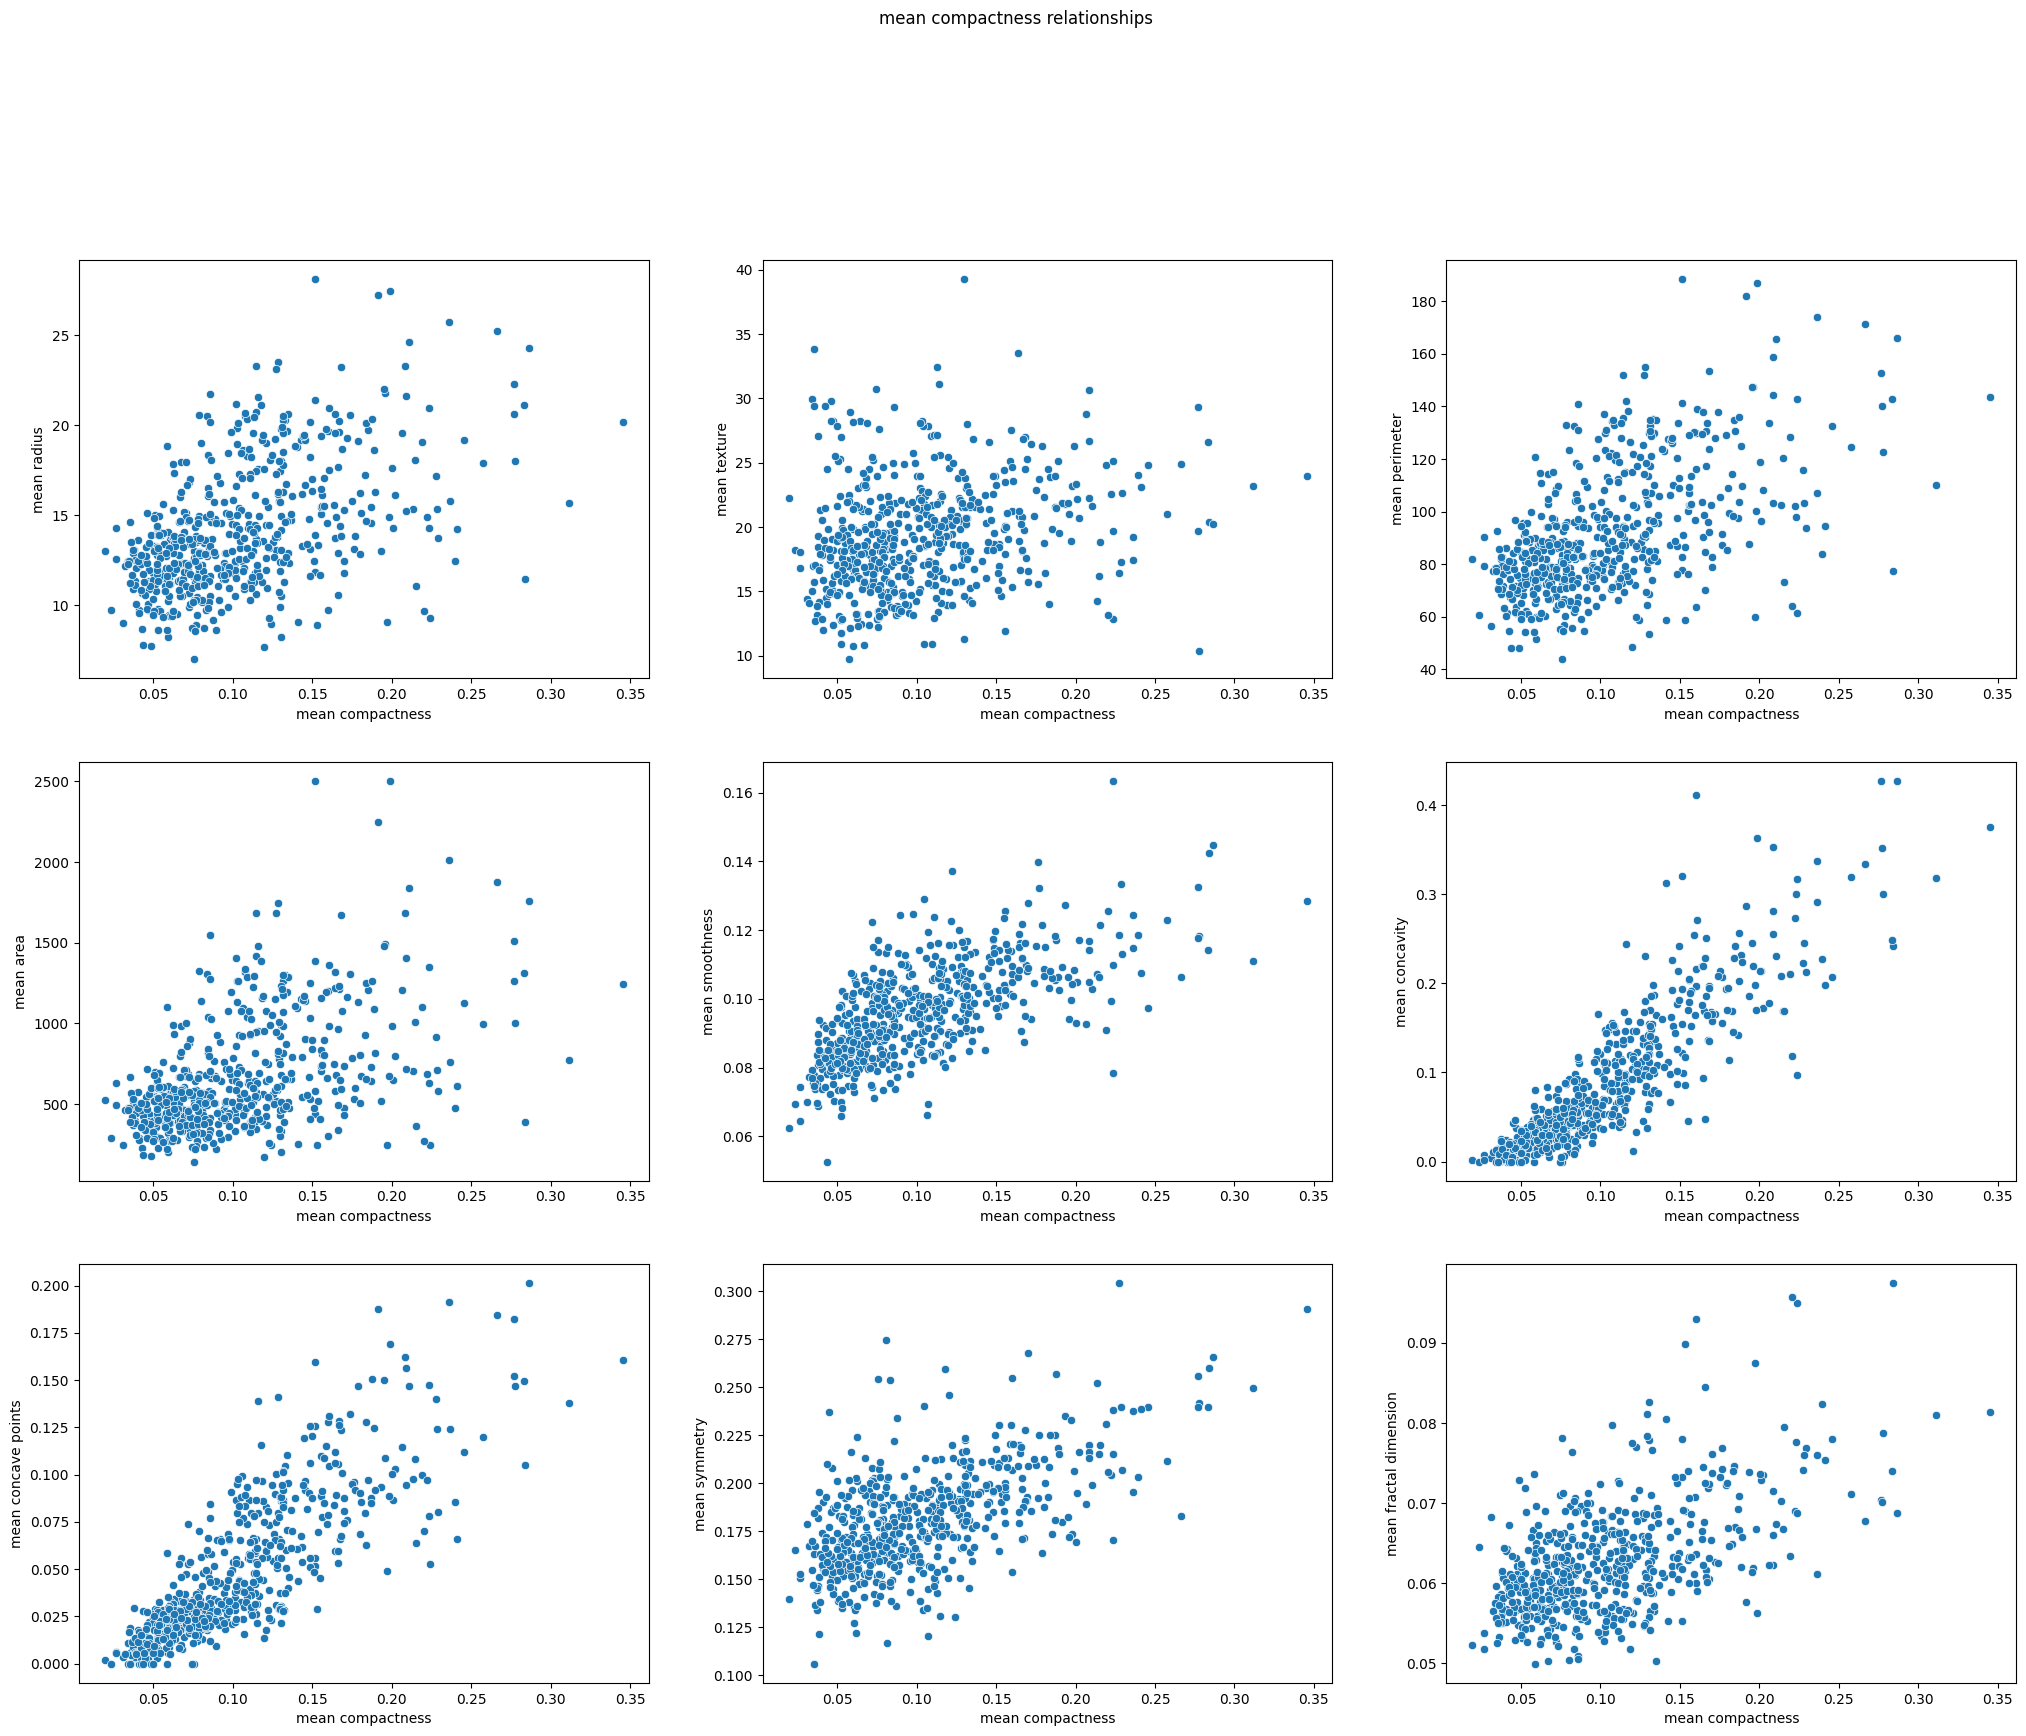

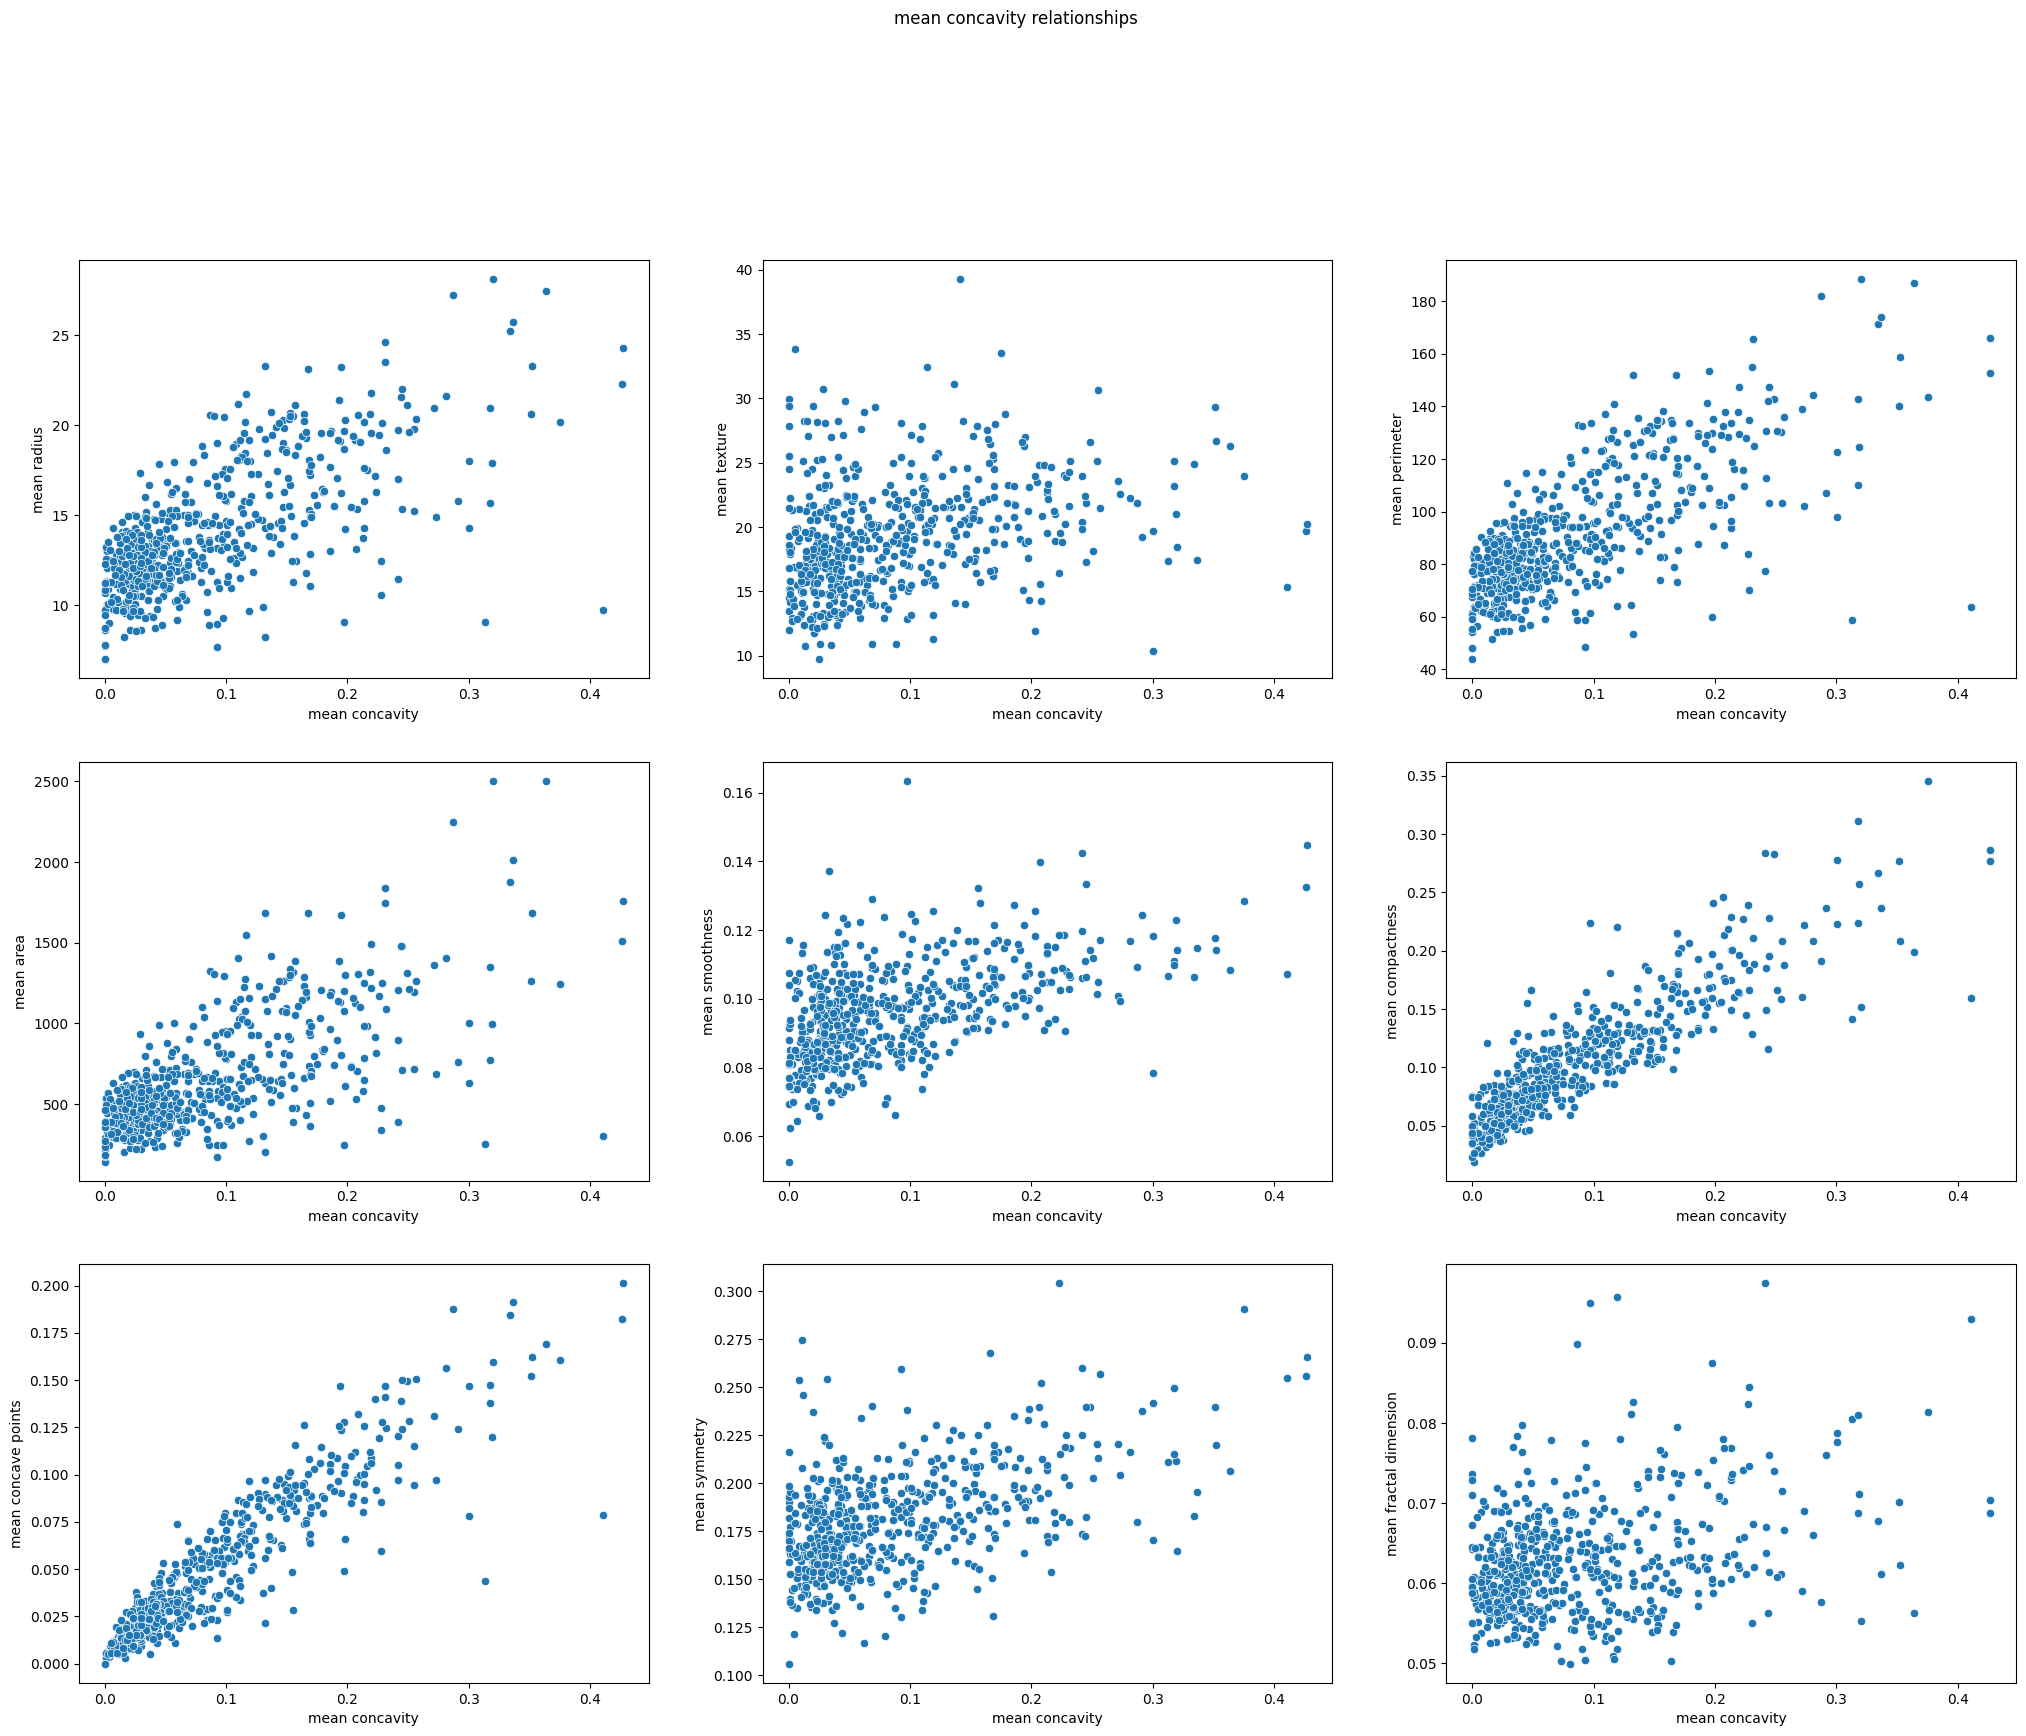

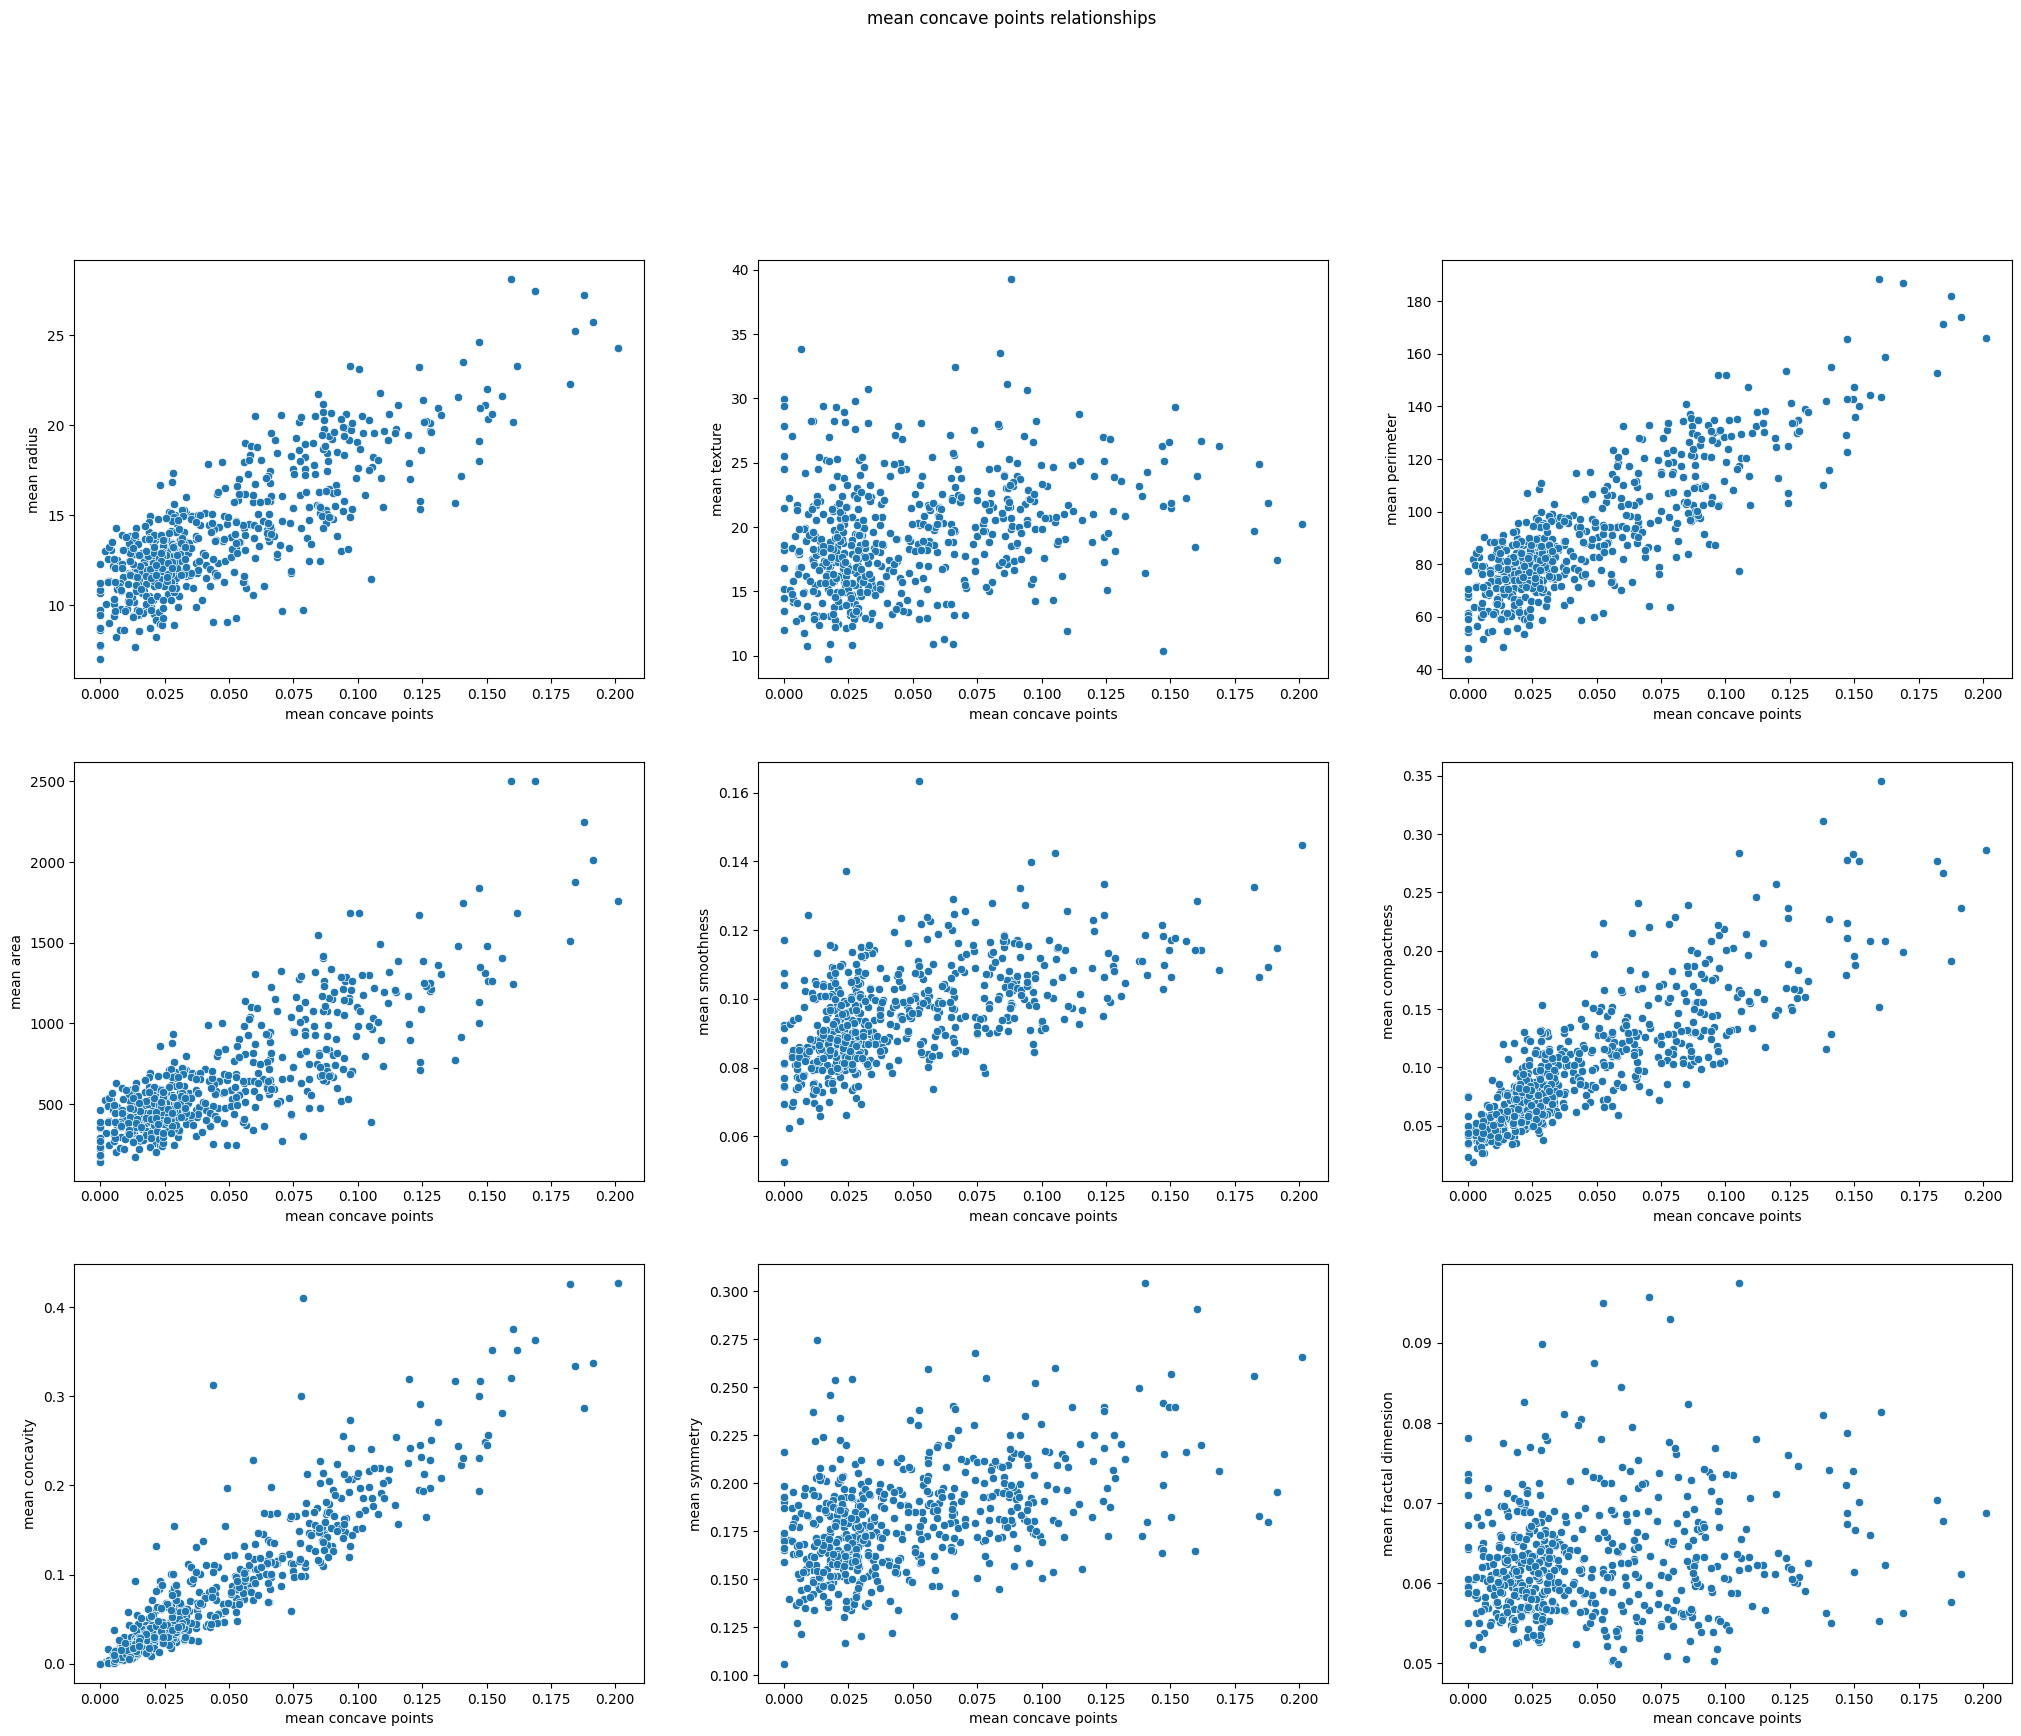

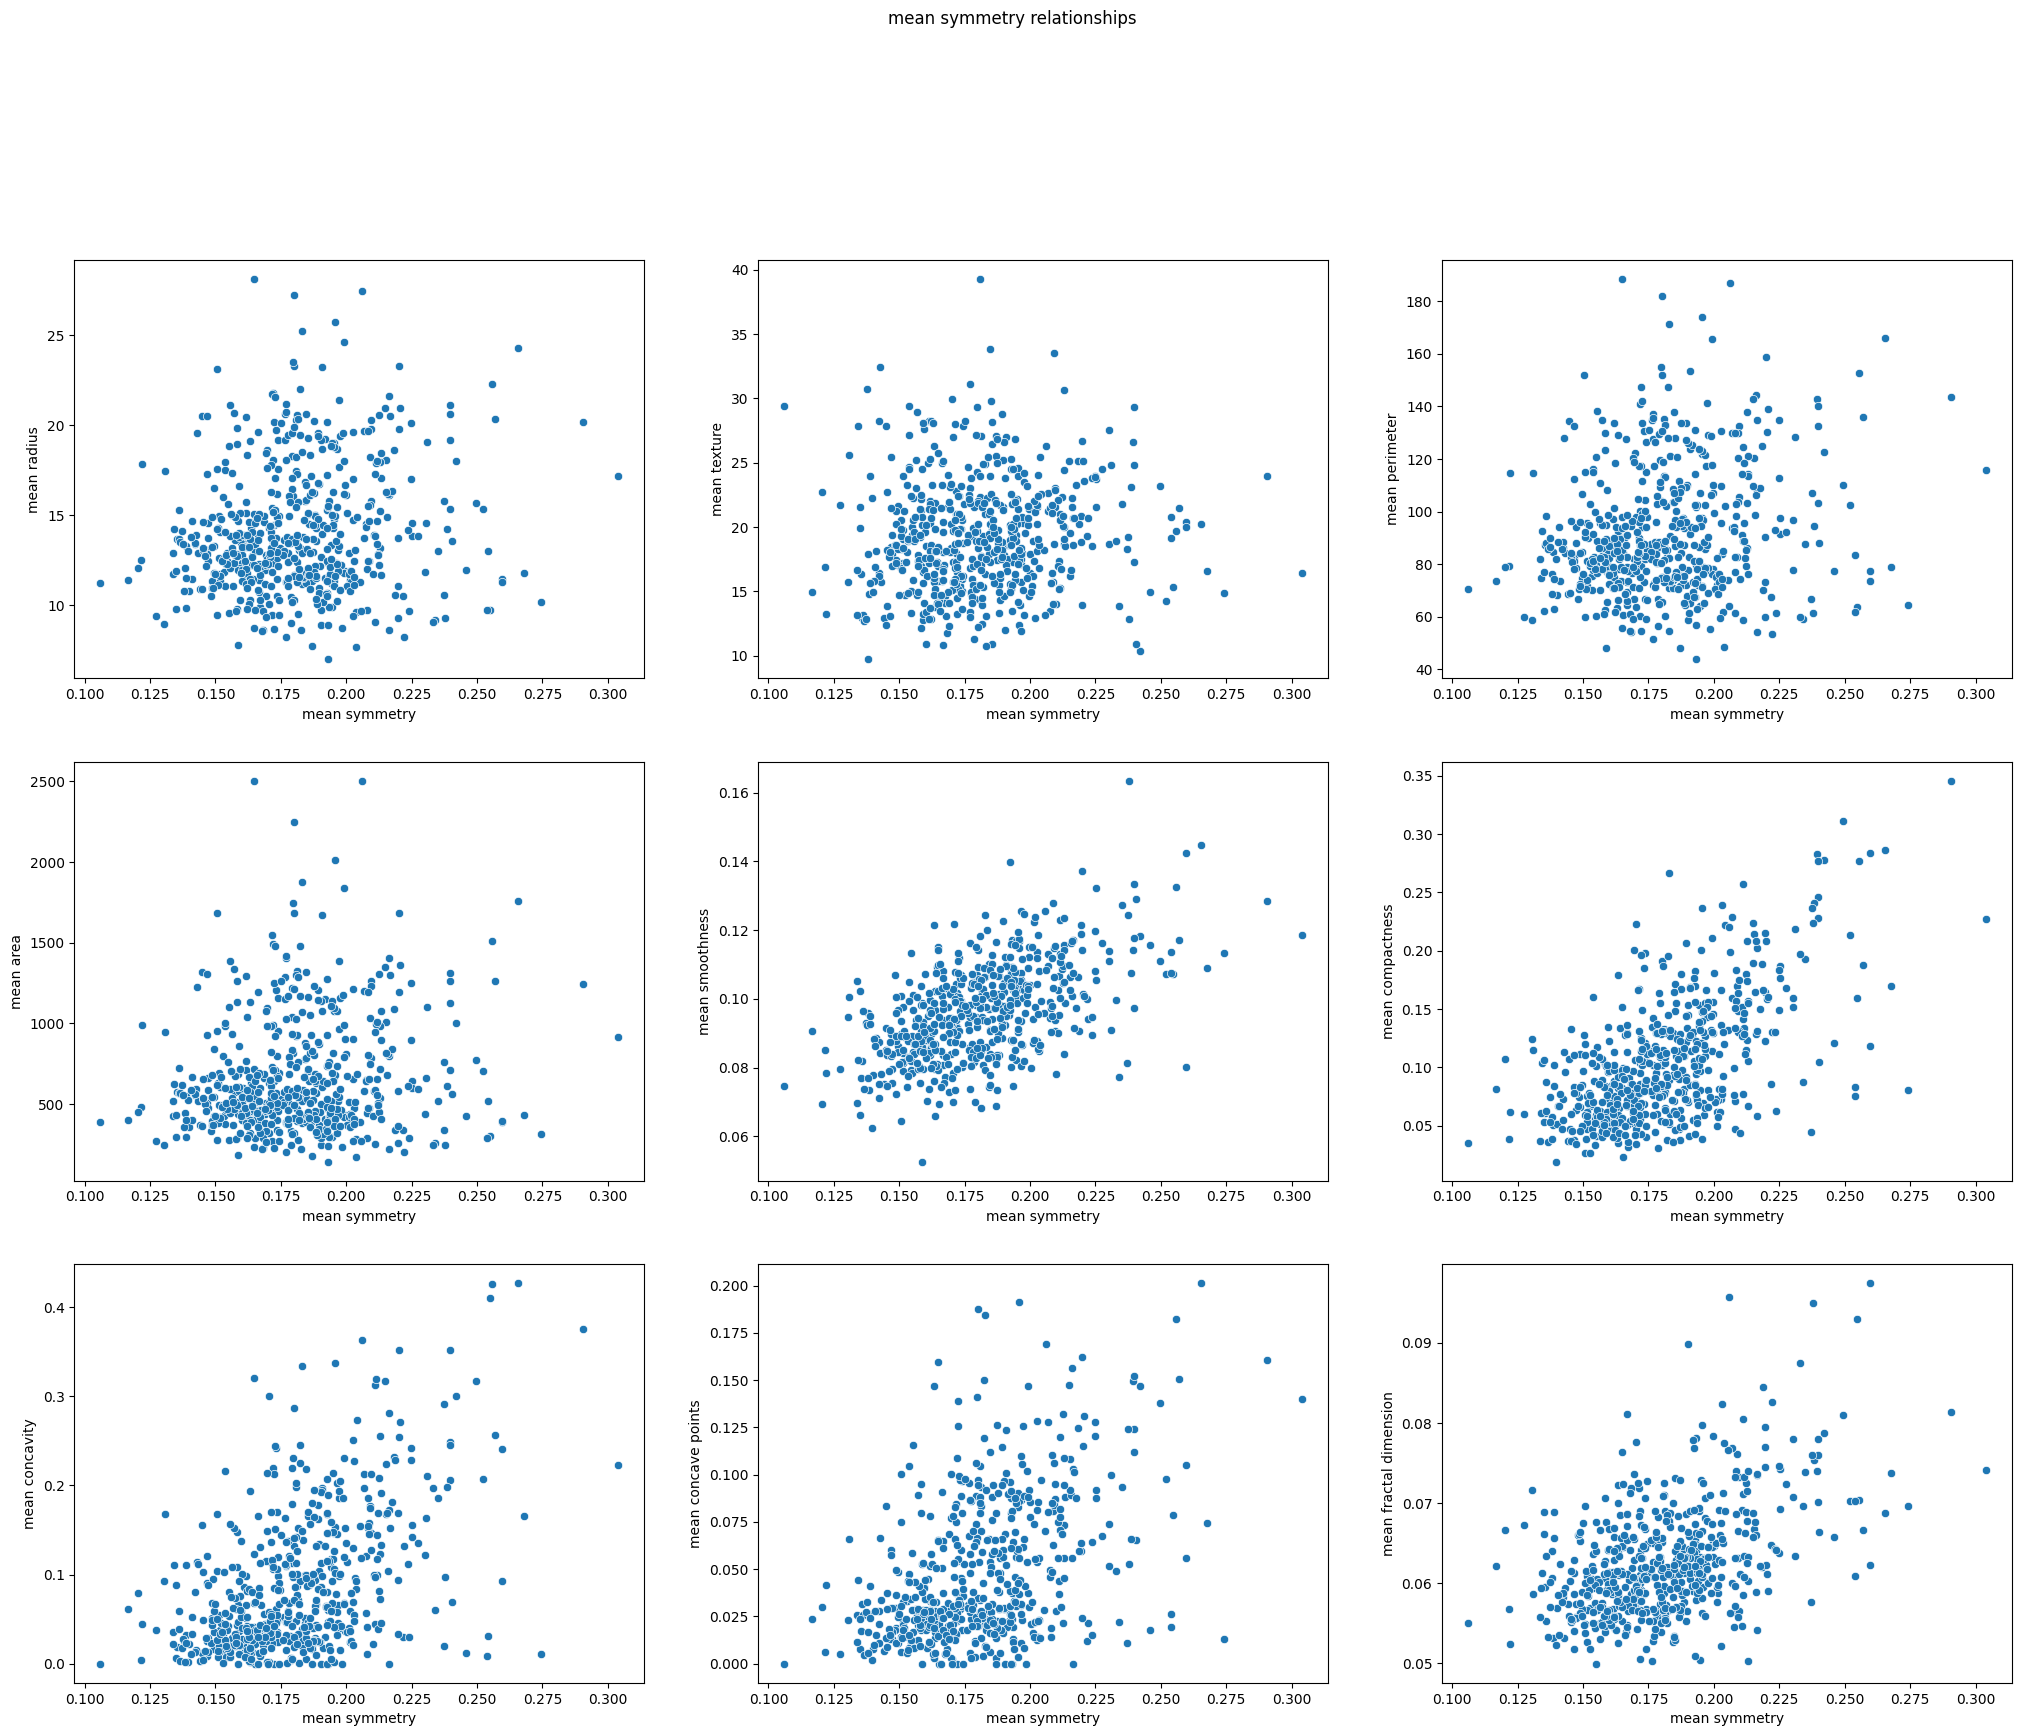

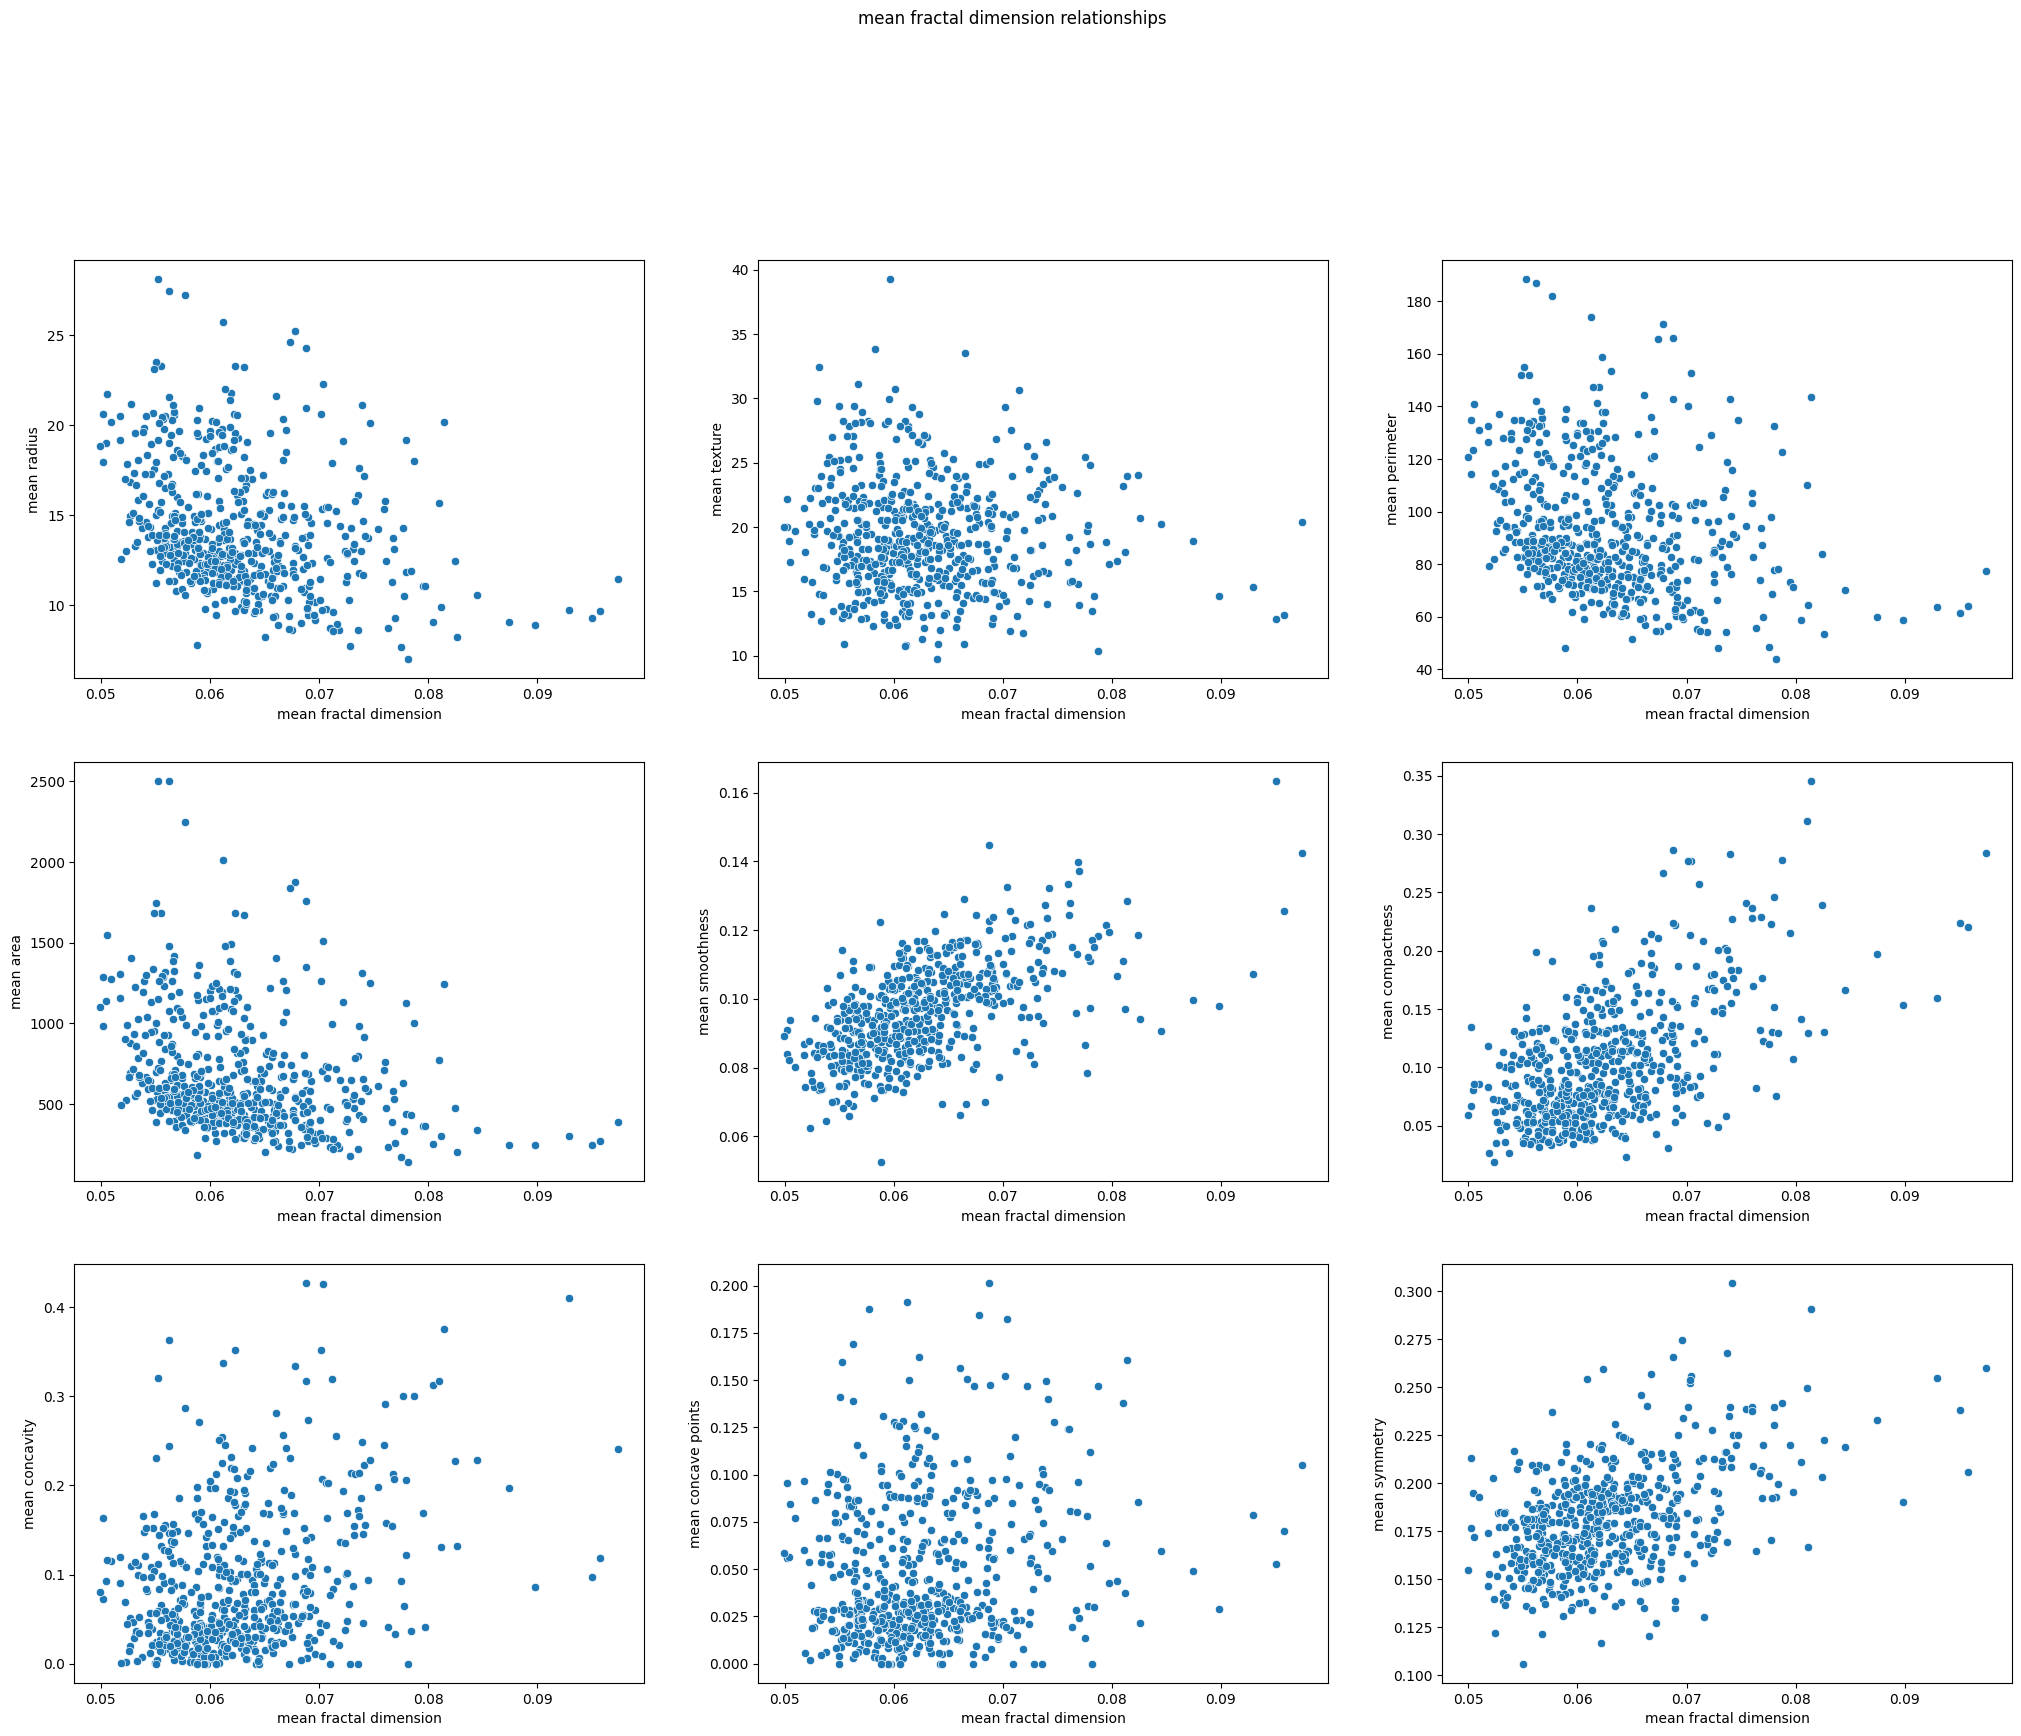

In [14]:
# scatter plot to understand the relationship
for c in df.columns:
  plt.figure(figsize=(25, 25))
  plt.suptitle(c + " relationships")
  index = 1
  for c1 in df.columns:
    if c != c1:
      plt.subplot(4, 3, index)
      sns.scatterplot(data=df, x=c, y=c1)
      index += 1
  index = 1
  plt.show()

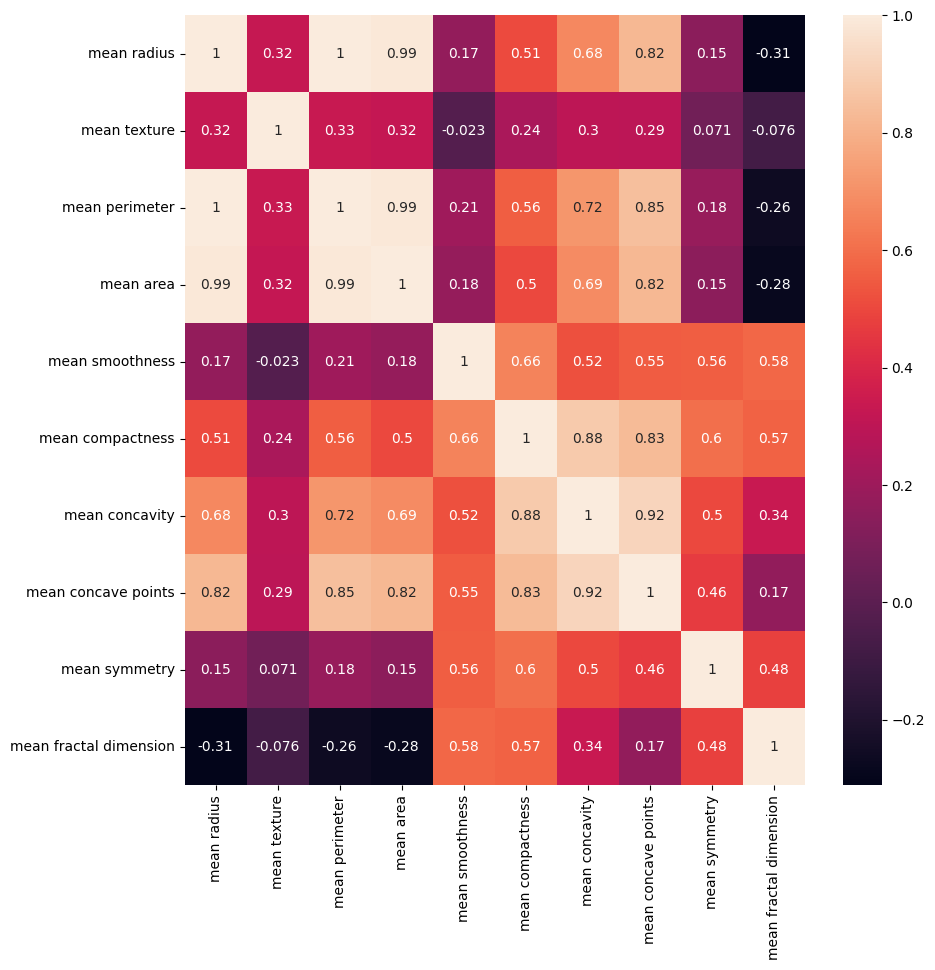

In [15]:
# correlation with heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(data=df.corr(), annot=True)
plt.show()

Note: since there are some highly correlated variables which cause multicollinearity, handling multicollinearity is necessary because of several reasons: it often leads to distorting estimation of regression coefficients, inflating standard errors, and thereby, reducing statistical power of the model.

In [16]:
# Using combination of VIF and dropping redundant features to address multicollinearity
# Note: a feature is considered redundant when it can be explained by other features. In other words, they are highly correlated to each other
exog = add_constant(data=df) # adding a const col serves as the intercept (performing a design matrix) since VIF relies on linear regression models
vifs = [round(variance_inflation_factor(exog=exog, exog_idx=i), 4) for i in range(exog.shape[1])]
table = pd.DataFrame()
table["features"] = exog.columns
table["VIFs"] = vifs
table = table.drop(labels=0, axis=0)

* VIF < 5: safe to keep
* VIF >= 5: consider removing
* VIF > 10: remove
* Note: sometimes dropping features with high VIF is not a good idea since it may cause information loss.

In [17]:
table

,features,VIFs
1,mean radius,1606.8058
2,mean texture,1.1870
3,mean perimeter,1956.1354
4,mean area,56.2840
5,mean smoothness,2.9571
6,mean compactness,22.6195
7,mean concavity,11.7152
8,mean concave points,21.7120
9,mean symmetry,1.7785
10,mean fractal dimension,6.4728


In [18]:
droppingFeatures = ["mean radius", "mean perimeter", "mean concave points"]
df = df.drop(labels=droppingFeatures, axis=1)

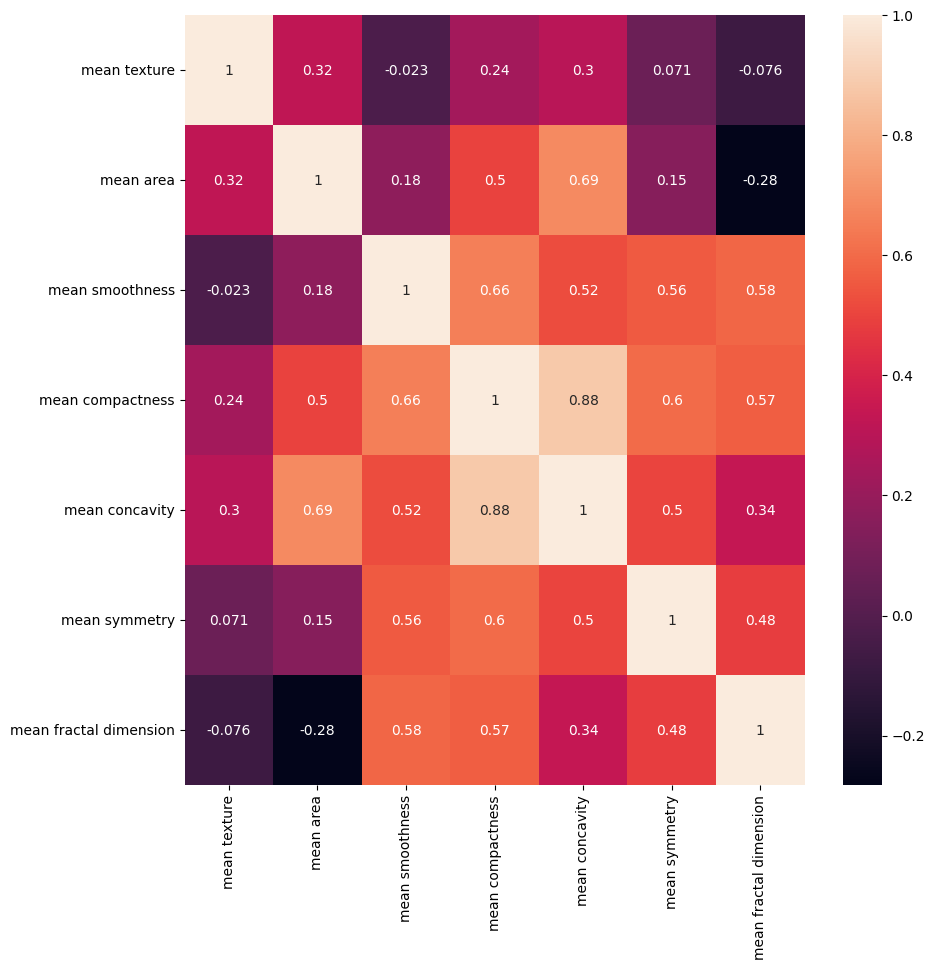

In [19]:
plt.figure(figsize=(10, 10))
sns.heatmap(data=df.corr(), annot=True)
plt.show()

don't just look at heatmap, the VIF is more accurate, because one variable could be highly correlated with linear combination of more than one other variables.

* correlation matrix measures pairwise linear relationships between two features at a time.

* VIF measures how much the variance of a regression coefficient is inflated due to linear dependence with all other features. It captures linear combinations of multiple items

In [20]:
exog = add_constant(data=df)
vifs = [round(variance_inflation_factor(exog=exog, exog_idx=i), 4) for i in range(exog.shape[1])]
table = pd.DataFrame()
table["features"] = exog.columns
table["VIFs"] = vifs
table = table.drop(labels=0, axis=0)

In [21]:
table

,features,VIFs
1,mean texture,1.1857
2,mean area,4.7683
3,mean smoothness,2.1888
4,mean compactness,8.6121
5,mean concavity,7.3787
6,mean symmetry,1.7464
7,mean fractal dimension,4.3127


4. Standardization (feature scaling)

Stadardization is important, it's a linear transformation, it makes the mean 0 and the standard deviation 1, it ensures that features are in the same scale.

if 2 variables are at different scales. This will result in one feature (larger scale) dominating the other one (smaller scale) which leads to poor performance.

> Standardization is preferred for models that assume a Gaussian distribution or use gradient-based optimization. Feature scaling is necessary for Logistic Regression since it's scale sensitive (it uses gradient descent to find best parameters).



In [22]:
x = df.iloc[:, 0:]
df["target"] = cancer.target # Adding target col into that dataframe, because the pandas dataframe itself does not add the target col by default
y = df.loc[:, "target"]

In [23]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [24]:
pd.DataFrame(data=x).describe().round(2)

,0,1,2,3,4,5,6
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.23,-1.45,-3.11,-1.61,-1.11,-2.74,-1.82
25%,-0.73,-0.67,-0.71,-0.75,-0.74,-0.70,-0.72
50%,-0.10,-0.30,-0.03,-0.22,-0.34,-0.07,-0.18
75%,0.58,0.36,0.64,0.49,0.53,0.53,0.47
max,4.65,5.25,4.77,4.57,4.24,4.48,4.91


5. Data splitting and imbalanced data

In [25]:
df.value_counts(subset=["target"])

target
1         357
0         212
Name: count, dtype: int64

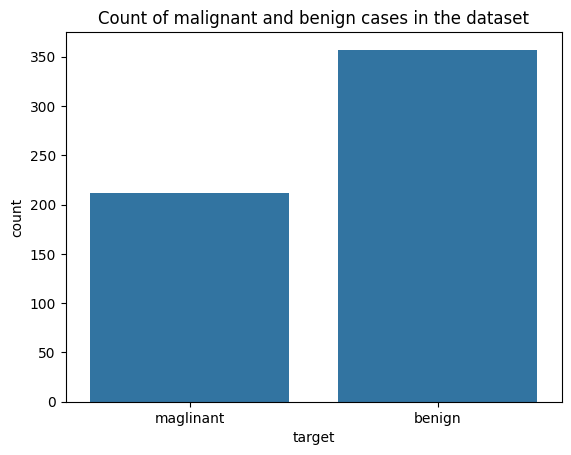

In [26]:
plt.title("Count of malignant and benign cases in the dataset")
sns.countplot(x=df["target"].map({0 : "malignant", 1: "benign"}))
plt.show()

Note: the data here is moderate imbalanced (which means resampling is optional):
* total samples: 569
* target0 (malignant): is the minority class because 212/569 = 0.37, meaning it's 37% of the dataset.
* target1 (benign): is the majority class because 357/569 = 0.63, meaning it's 63% of the dataset.
> Here using SMOTE to over-sample is good, Note: split the dataset then apply SMOTE on training set only, because if we do the opposite, it may leak test data which causes the model overfit or give overly optimistic results.



Note: random_state=42 (this helps get the same split or same synthetic samples every time the code runs), 42 here is just a fun default value because of the famous joke:

> "42 is the answer to the ultimate question of life, the universe,
and everything" --Douglas Adam, The Hitchhiker's Guide to the Galaxy



In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, shuffle=True, test_size=0.2, random_state=42)

In [28]:
y_train.value_counts()

target
1    286
0    169
Name: count, dtype: int64

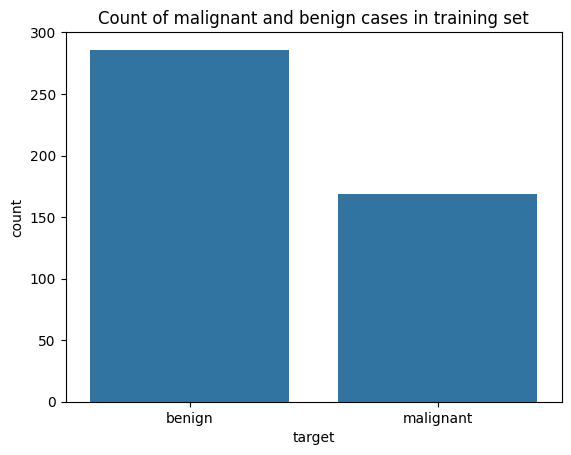

In [29]:
plt.title("Count of malignant and benign cases in training set")
sns.countplot(x=y_train.map({0 : "malignant", 1 : "benign"}))
plt.show()

In [30]:
sm = SMOTE(random_state=42)
x_train, y_train = sm.fit_resample(x_train, y_train)

In [31]:
y_train.value_counts()

target
1    286
0    286
Name: count, dtype: int64

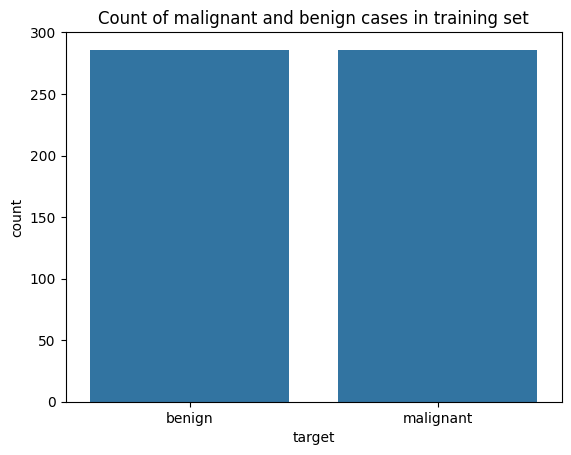

In [32]:
plt.title("Count of malignant and benign cases in training set")
sns.countplot(x=y_train.map({0 : "malignant", 1 : "benign"}))
plt.show()

# TRAIN AND TEST MODEL

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [34]:
lr = LogisticRegression()
clf = lr.fit(x_train, y_train)

In [35]:
y_pred = clf.predict(x_test)
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.97        43
      benign       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



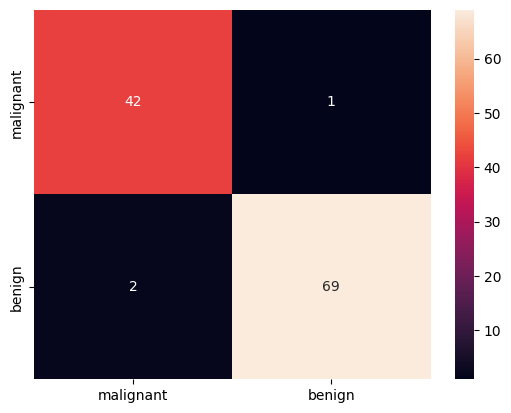

In [39]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.show()

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
joblib.dump(clf, "logistic_model.pkl")

In [ ]:
joblib.dump(scaler, "scaler.pkl")